# EPPO Fine-Tuning: BC Warm Start → PPO with Session Architecture

## Architecture
```
GLOBAL concept pool (all uploaded courses, ~115 concepts)
    │
    │  Student: 'I want to study OS scheduling'
    ▼
SESSION PRE-SELECTION
  cap = MAX_STEPS // 3 = 20
  rank by P(correct|Hard) ascending → take weakest N
  tie-break: LLM difficulty → random
    │
    ▼
SESSION SCOPE (13-20 concepts)
  Agent assigns ONLY within scope
  PFA propagation uses GLOBAL similarity graph
    │
    ▼
GOAL: master max(1, round(not_yet_mastered × 0.30)) NEW concepts
      mastered = P(correct|Hard) > 0.68
```

## Training: 5000 episodes × 60 steps = 288k transitions, ~45 min T4

## Cell 1: Imports

In [54]:
import subprocess
subprocess.run(['pip','install','sentence-transformers','-q'],check=True)

import numpy as np, torch, torch.nn as nn, torch.optim as optim
from torch.distributions import Categorical
from sentence_transformers import SentenceTransformer
from collections import defaultdict
import math, warnings, os
import matplotlib; import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.figsize']=(18,5)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available(): print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## Cell 2: Global Concept Pool

5 simulated courses (~115 concepts). **In production:** replace COURSES with LLM extractor output from uploaded PDFs.

In [55]:
# (concept_name, llm_difficulty_1_to_5)
COURSES = {
    'algorithms': [
        ('time complexity analysis',2),('space complexity analysis',2),
        ('recursion',2),('divide and conquer',3),('sorting algorithms',2),
        ('merge sort',3),('quick sort',3),('binary search',2),
        ('binary search tree',3),('balanced BST',4),
        ('graph traversal BFS DFS',3),('shortest path Dijkstra',4),
        ('dynamic programming basics',4),('memoization',3),
        ('greedy algorithms',3),('hash table',2),
        ('heap and priority queue',3),('dynamic programming advanced',5),
    ],
    'operating_systems': [
        ('process vs thread',2),('process scheduling',3),
        ('FCFS scheduling',2),('round robin scheduling',3),
        ('priority scheduling',3),('multilevel queue scheduling',4),
        ('process synchronization',4),('mutex and semaphore',3),
        ('deadlock conditions',3),('deadlock prevention',4),
        ('deadlock detection recovery',4),('memory management basics',3),
        ('paging',3),('segmentation',4),('virtual memory',4),
        ('page replacement algorithms',4),('thrashing',5),
        ('file system structure',3),('disk scheduling',3),('I/O management',4),
    ],
    'computer_networks': [
        ('OSI model layers',2),('TCP IP stack',3),
        ('IP addressing',2),('subnetting CIDR',3),
        ('routing fundamentals',3),('routing protocols RIP OSPF',4),
        ('TCP connection management',3),('TCP congestion control',4),
        ('UDP vs TCP',2),('DNS',2),('HTTP HTTPS',2),
        ('network security basics',3),('TLS SSL handshake',4),
        ('firewalls and NAT',3),('wireless networking',3),
        ('network performance metrics',3),('software defined networking',5),
    ],
    'computer_architecture': [
        ('binary and number systems',1),('logic gates',2),
        ('combinational circuits',3),('sequential circuits',3),
        ('CPU datapath',3),('instruction set architecture',3),
        ('CPU pipeline stages',4),('pipeline hazards',4),
        ('branch prediction',4),('cache memory',3),('cache coherence',5),
        ('memory hierarchy',3),('virtual memory hardware',4),
        ('multicore architecture',4),('GPU architecture basics',4),('SIMD parallelism',4),
    ],
    'software_engineering': [
        ('software development lifecycle',2),('agile and scrum',2),
        ('design patterns',3),('SOLID principles',3),
        ('object oriented design',3),('UML diagrams',3),
        ('version control git',2),('testing strategies',3),
        ('unit testing',3),('integration testing',3),
        ('CI CD pipelines',4),('microservices architecture',4),
        ('REST API design',3),('database design',3),
        ('system design scalability',5),('security in software',4),
        ('code review practices',2),('refactoring',3),
    ],
}

GLOBAL_CONCEPTS=[]; GLOBAL_LLM_DIFF=[]; COURSE_CONCEPT_INDICES={}
for cname,concepts in COURSES.items():
    idxs=[]
    for name,diff in concepts:
        GLOBAL_CONCEPTS.append(name); GLOBAL_LLM_DIFF.append(diff)
        idxs.append(len(GLOBAL_CONCEPTS)-1)
    COURSE_CONCEPT_INDICES[cname]=idxs
N_GLOBAL=len(GLOBAL_CONCEPTS)
print(f'Global pool: {N_GLOBAL} concepts across {len(COURSES)} courses')
for cn,ci in COURSE_CONCEPT_INDICES.items():
    print(f'  {cn:<25}: {len(ci)} concepts')

Global pool: 89 concepts across 5 courses
  algorithms               : 18 concepts
  operating_systems        : 20 concepts
  computer_networks        : 17 concepts
  computer_architecture    : 16 concepts
  software_engineering     : 18 concepts


## Cell 3: Config

In [56]:
class Config:
    N_LEVELS=3; LEVEL_NAMES=['Easy','Medium','Hard']
    GAMMA_LEVEL=np.array([0.0330,0.1494,0.8884])
    RHO_LEVEL  =np.array([0.1444,0.3433,0.2331])
    BETA_LEVEL =np.array([1.4333,1.0389,0.4271])
    LLM_BETA_SCALE=-0.4; LLM_BETA_MID=3.0
    PFA_TOP_K=5; PFA_ALPHA=0.04; SIM_THRESHOLD=0.45
    MAX_STEPS=60
    CONCEPT_CAP=10   # reduced from 20 → 10
    # 10 concepts × 60 steps = 6 steps/concept minimum
    # Agent can meaningfully practice each concept, not just touch it once

    # ── APR-based goal: relative improvement from session start ──────
    # Goal = APR_final >= APR_start × (1 + IMPROVEMENT_PCT)
    #
    # Why relative and not fixed:
    #   Fixed +0.05 is too easy for beginners (APR=0.50 → needs 0.55)
    #   and unreachable for advanced students (APR=0.92 → needs 0.97).
    #   A percentage scales with the student's current level:
    #     beginner   APR=0.55 → target=0.55×1.07=0.589  (+0.039 absolute)
    #     average    APR=0.70 → target=0.70×1.07=0.749  (+0.049 absolute)
    #     advanced   APR=0.85 → target=0.85×1.07=0.910  (+0.060 absolute)
    #   Advanced students face a harder absolute challenge — correct,
    #   because they need Hard assignments to move their already-high APR.
    #
    # IMPROVEMENT_PCT=0.07 (7%) rationale:
    #   At average APR=0.70, target=0.749. Each correct Hard answer moves
    #   P(correct|Hard) ~+0.025. With 10 concepts × 6 steps, reaching
    #   +0.049 absolute requires consistent correct answers across concepts.
    #   Too easy: 0.03 (random achieves this). Too hard: 0.15 (ceiling issue).
    IMPROVEMENT_PCT    = 0.07   # 7% relative improvement from session start
    SESSION_DONE_BONUS = 10.0   # reward when goal met before MAX_STEPS

    # Mastery threshold kept for tracking/logging only — not for goal
    MASTERY_THRESHOLD = 0.65
    EMBED_MODEL='BAAI/bge-base-en-v1.5'; EMBED_DIM=768
    # State dim expanded from 14→19 (5 new relative concept features)
    # SCORER_IN = STATE_DIM + N_LEVELS = 19+3 = 22
    STATE_DIM=19; SCORER_IN=22; HIDDEN_DIM=64
    ITEM_DIFFICULTY=np.array([0.0,1.0,2.2])
    SLIP=0.08; GUESS=0.15; LEARN_RATE=0.10; FORGET_RATE=0.003; TRANSFER_ALPHA=0.25
    # Reward rebalancing:
    # W_BONUS raised to 8.0 — mastery must dominate over step rewards
    # W_CORRECT lowered to 0.3 — reduce safe easy-answer exploitation
    # W_PROGRESS raised to 3.0 — stronger signal for actual PFA improvement
    # W_FIT raised to 0.5 — stronger penalty for Easy on capable students
    # W_DIV raised to 0.4 — stronger diversity to prevent concept fixation
    # Reward redesign — aligned with PFA delta magnitudes:
    # Easy correct gives Δ=+0.004, Hard correct gives Δ=+0.134 (38x more)
    # W_PROGRESS must be large enough that Hard steps dominate the return
    W_CORRECT      = 0.2    # very small — prevent Easy exploitation
    W_PROGRESS     = 8.0    # raised: 8.0 × 0.134 = 1.07 per Hard correct
    W_BONUS        = 5.0    # mastery crossing (reduced — progress signal stronger now)
    W_FIT          = 0.5    # difficulty mismatch penalty
    W_DIV          = 0.3    # diversity penalty
    W_HARD_CORRECT = 1.0    # bonus on top for correct Hard (was 0.5)
    LR_ACTOR=5e-5; LR_CRITIC=2e-4; GAMMA=0.99; GAE_LAMBDA=0.95
    # LR halved: policy is good at ep4200, refine don't overwrite
    # LR_ACTOR raised: BC is biased toward Easy/Medium (46%/39% of training data)
    # Policy needs to shift toward Hard faster than LR=5e-5 allows
    # LR_ACTOR lowered further — PPO was overwriting BC warm start too fast
    # ENTROPY_COEF raised — encourage exploration of Hard assignments
    # PPO_EPOCHS reduced to 2 — less aggressive updates per episode
    # ENTROPY_COEF raised further: 0.10 — PPO must maintain Hard exploration
    # CLIP_EPS raised to 0.15 — allow larger updates to escape Easy attractor
    # PPO_EPOCHS kept at 2 — don't over-fit per episode
    CLIP_EPS=0.10; ENTROPY_COEF=0.03; VALUE_COEF=0.5; PPO_EPOCHS=2; GRAD_CLIP=0.5
    # Tighter clip + lower entropy for continuation:
    # policy at ep4200 is already good — small refinements only
    N_EPISODES      = 8000   # continuation episodes (on top of prior run)
    WARMUP_EPISODES = 0      # no warmup — resuming from trained checkpoint
    LOG_EVERY       = 100
    SAVE_EVERY      = 500
    # Hard floor: minimum fraction of Hard assignments per episode
    # Hard correct gives 38x more PFA delta than Easy — essential for APR
    HARD_FLOOR      = 0.40
    # Policy is now mature (~ep4200) — use full cross-course diversity
    P_ONE_COURSE = 0.50
    # BC from DBE-KT22 (database concepts) provides near-zero benefit
    # for RL on CS concepts. Training from scratch with longer warmup.
    BC_ACTOR_PATH = ''   # not used
    # ── Resume from previous checkpoint ───────────────────────────────
    # Upload eppo_best.pt from previous run as a Kaggle dataset input
    # then set the path here:
    RESUME_PATH   = '/kaggle/input/eppo-checkpoint/eppo_best.pt'
    # Alternative if running in same Kaggle session:
    # RESUME_PATH = '/kaggle/working/eppo_best.pt'
    SAVE_PATH='/kaggle/working/'
    DEVICE=DEVICE

cfg=Config()
train_eps=cfg.N_EPISODES-cfg.WARMUP_EPISODES
total_trans=train_eps*cfg.MAX_STEPS
print(f'Training adequacy:')
print(f'  Transitions    : {total_trans:,}')
print(f'  Actions/session: ~{cfg.CONCEPT_CAP*cfg.N_LEVELS}')
print(f'  Visits/action  : ~{total_trans//(cfg.CONCEPT_CAP*cfg.N_LEVELS)}')
print(f'  GPU time (T4)  : ~{cfg.N_EPISODES*cfg.MAX_STEPS//6000} min')
print(f'  Kaggle OK      : {cfg.N_EPISODES*cfg.MAX_STEPS//6000 < 680}')

Training adequacy:
  Transitions    : 480,000
  Actions/session: ~30
  Visits/action  : ~16000
  GPU time (T4)  : ~80 min
  Kaggle OK      : True


## Cell 4: Embeddings + Global Similarity Graph

In [57]:
print(f'Loading {cfg.EMBED_MODEL}')
embed_model=SentenceTransformer(cfg.EMBED_MODEL)
print(f'Embedding {N_GLOBAL} concepts...')
global_embeddings=embed_model.encode(
    GLOBAL_CONCEPTS,normalize_embeddings=True,
    show_progress_bar=True,batch_size=64
).astype(np.float32)
global_sim_matrix=(global_embeddings@global_embeddings.T)
global_neighbours=[]
for i in range(N_GLOBAL):
    s=global_sim_matrix[i].copy(); s[i]=-1
    mask=s>=cfg.SIM_THRESHOLD
    if mask.sum()==0: top=np.array([np.argmax(s)])
    else: top=np.where(mask)[0][np.argsort(-s[mask])[:cfg.PFA_TOP_K]]
    global_neighbours.append(top)
print(f'Embedding shape : {global_embeddings.shape}')
print(f'Avg neighbours  : {np.mean([len(n) for n in global_neighbours]):.1f} (threshold={cfg.SIM_THRESHOLD})')

print('\nSample cross-course pairs (sim > 0.60):')
shown=0
for i in range(N_GLOBAL):
    for j in global_neighbours[i]:
        ci_c=next(c for c,idxs in COURSE_CONCEPT_INDICES.items() if i in idxs)
        cj_c=next(c for c,idxs in COURSE_CONCEPT_INDICES.items() if j in idxs)
        if ci_c!=cj_c and global_sim_matrix[i,j]>0.60:
            print(f'  [{ci_c[:8]}] {GLOBAL_CONCEPTS[i]}')
            print(f'    ↔ [{cj_c[:8]}] {GLOBAL_CONCEPTS[j]}  sim={global_sim_matrix[i,j]:.3f}')
            shown+=1
            if shown>=5: break
    if shown>=5: break

Loading BAAI/bge-base-en-v1.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding 89 concepts...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding shape : (89, 768)
Avg neighbours  : 5.0 (threshold=0.45)

Sample cross-course pairs (sim > 0.60):
  [algorith] time complexity analysis
    ↔ [computer] sequential circuits  sim=0.722
  [algorith] space complexity analysis
    ↔ [software] system design scalability  sim=0.670
  [algorith] recursion
    ↔ [computer] binary and number systems  sim=0.660
  [algorith] divide and conquer
    ↔ [computer] binary and number systems  sim=0.658
  [algorith] quick sort
    ↔ [operatin] paging  sim=0.657


## Cell 5: PFA Tracker (Global + Session Scope)

- Maintains state for ALL N_GLOBAL concepts
- `start_session(indices)` — sets scope, computes goal
- `update(ci,level,correct)` — updates PFA + propagates globally
- `get_state_features(ci)` — 14-scalar input for actor (session-scoped global features)
- Global propagation flows to all similar concepts regardless of course

In [58]:
def sigmoid(x): return 1./(1.+np.exp(-np.clip(x,-15,15)))

class PFATracker:
    def __init__(self,cfg):
        self.cfg=cfg; N=N_GLOBAL; L=cfg.N_LEVELS
        self.gamma_level=cfg.GAMMA_LEVEL.copy()
        self.rho_level=cfg.RHO_LEVEL.copy()
        self.beta_level=cfg.BETA_LEVEL.copy()
        self.beta_concept=np.array([(d-cfg.LLM_BETA_MID)*cfg.LLM_BETA_SCALE
                                     for d in GLOBAL_LLM_DIFF],dtype=np.float32)
        self.successes=np.zeros((N,L),dtype=np.float32)
        self.failures =np.zeros((N,L),dtype=np.float32)
        self.propagation_bonus=np.zeros((N,L),dtype=np.float32)
        self.session_indices=[]; self.session_mastered_before=set()
        self.session_mastered_now=set()
        self.apr_start=0.; self.apr_target=0.; self.apr_improvement_needed=0.
        self.action_history={}

    def reset_global(self,prior_history=None):
        N,L=N_GLOBAL,self.cfg.N_LEVELS
        if prior_history is None:
            self.successes=np.zeros((N,L),dtype=np.float32)
            self.failures =np.zeros((N,L),dtype=np.float32)
            self.propagation_bonus=np.zeros((N,L),dtype=np.float32)
        else:
            self.successes=prior_history['successes'].copy()
            self.failures =prior_history['failures'].copy()
            self.propagation_bonus=prior_history['bonuses'].copy()

    def start_session(self, session_indices):
        """
        Begin a session with the given concept subset.

        Goal definition (APR-based):
          apr_start  = mean P(correct) across session concepts RIGHT NOW
          apr_target = apr_start × (1 + IMPROVEMENT_PCT)
          Goal met   = current session APR >= apr_target

        This is continuous and always measurable. No threshold crossing
        required. A student who improves every concept by a small amount
        achieves the goal. A student who masters one concept but ignores
        the others may not.
        """
        self.session_indices = list(session_indices)
        self.action_history  = {}
        self.session_mastered_now = set()   # still tracked for logging

        # Compute session-start weights for WAPR
        # weight(ci) = 1 - P(correct|Hard) at session start
        # Weaker concepts get higher weight — improving them matters more
        all_p_start = self.predict_all_global()
        p_hard_start = all_p_start[self.session_indices, 2]  # (N_sess,)
        raw_weights  = 1.0 - p_hard_start                    # (N_sess,)
        total_w = raw_weights.sum()
        self.session_weights = raw_weights / total_w  # normalised
        # ^ shape (N_sess,), sums to 1.0

        # Adaptive improvement target — scales down for harder sessions
        # Harder session scope (low mean P(Hard)) → lower required improvement
        # This prevents later sessions always failing on hardest concepts
        mean_p_hard_sess = float(all_p_start[self.session_indices, 2].mean())
        # difficulty_factor: 1.0 when P(Hard)=0.65, 0.5 when P(Hard)=0.42
        difficulty_factor = float(np.clip(mean_p_hard_sess / 0.65, 0.50, 1.0))
        effective_pct     = self.cfg.IMPROVEMENT_PCT * difficulty_factor

        # WAPR-based goal
        self.wapr_start  = self.compute_session_wapr()
        self.wapr_target = min(0.97, self.wapr_start * (1.0 + effective_pct))
        self.wapr_improvement_needed = self.wapr_target - self.wapr_start
        self.effective_improvement_pct = effective_pct  # for logging

        # Keep plain APR for backward compat
        self.apr_start  = self.compute_session_apr()
        self.apr_target = min(0.97, self.apr_start * (1.0 + self.cfg.IMPROVEMENT_PCT))
        self.apr_improvement_needed = self.apr_target - self.apr_start

        # Mastery tracking for logs (not for goal)
        self.session_mastered_before = {
            ci for ci in self.session_indices
            if self.predict(ci, 2) > self.cfg.MASTERY_THRESHOLD
        }

        return {
            'n_session_concepts'     : len(self.session_indices),
            'already_mastered'       : len(self.session_mastered_before),
            # Plain APR goal
            'apr_start'              : self.apr_start,
            'apr_target'             : self.apr_target,
            'improvement_needed'     : self.apr_improvement_needed,
            # Weighted APR goal
            'wapr_start'             : self.wapr_start,
            'wapr_target'            : self.wapr_target,
            'wapr_improvement_needed': self.wapr_improvement_needed,
            'improvement_pct'        : self.cfg.IMPROVEMENT_PCT,
        }

    def predict(self,ci,level):
        k=level
        z=(self.beta_concept[ci]+self.beta_level[k]
           +self.gamma_level[k]*np.log1p(self.successes[ci,k])
           -self.rho_level[k]*np.log1p(self.failures[ci,k])
           +self.propagation_bonus[ci,k])
        return float(sigmoid(z))

    def predict_all_global(self):
        z=(self.beta_concept[:,None]+self.beta_level[None,:]
           +self.gamma_level[None,:]*np.log1p(self.successes)
           -self.rho_level[None,:]*np.log1p(self.failures)
           +self.propagation_bonus)
        return sigmoid(z)

    def compute_session_apr(self):
        all_p=self.predict_all_global()
        return float(all_p[self.session_indices].mean())

    def count_newly_mastered(self):
        return len(self.session_mastered_now)

    def compute_session_wapr(self):
        """
        Weighted APR over session concepts.
        weight(ci) = (1 - P(Hard)) at session start — weaker concepts count more.
        WAPR = Σ weight(ci) × mean_P(ci) / Σ weight(ci)
        """
        all_p   = self.predict_all_global()              # (N_global, L)
        sess_p  = all_p[self.session_indices]             # (N_sess, L)
        mean_p  = sess_p.mean(axis=1)                     # (N_sess,) mean over levels
        return float((self.session_weights * mean_p).sum())

    def goal_met(self):
        """Goal = WAPR >= wapr_target.
        Weighted so that improving weak concepts counts more.
        """
        return self.compute_session_wapr() >= self.wapr_target

    def wapr_improvement(self):
        """Current WAPR improvement from session start."""
        return self.compute_session_wapr() - self.wapr_start

    def apr_improvement(self):
        return self.compute_session_apr() - self.apr_start

    def compute_course_apr(self, course_name):
        """
        APR over ALL concepts in a course — consistent across sessions.
        Unlike session APR (scope changes each session), this measures
        total student knowledge across the full course.
        Should be monotonically increasing across sessions.
        """
        all_p          = self.predict_all_global()
        course_indices = COURSE_CONCEPT_INDICES[course_name]
        return float(all_p[course_indices].mean())

    def compute_course_wapr(self, course_name):
        """
        WAPR over ALL course concepts using session-start weights.
        Uses weights from most recent start_session call.
        """
        all_p          = self.predict_all_global()
        course_indices = COURSE_CONCEPT_INDICES[course_name]
        course_p_hard  = all_p[course_indices, 2]
        raw_w          = 1.0 - course_p_hard
        w              = raw_w / raw_w.sum()
        mean_p         = all_p[course_indices].mean(axis=1)
        return float((w * mean_p).sum())

    def update(self,ci,level,correct):
        k=level; p_before=self.predict(ci,k)
        if correct: self.successes[ci,k]+=1.
        else:       self.failures[ci,k]+=1.
        p_after=self.predict(ci,k)
        p_hard=self.predict(ci,2)
        was_mastered=(ci in self.session_mastered_before or ci in self.session_mastered_now)
        if p_hard>self.cfg.MASTERY_THRESHOLD and not was_mastered:
            self.session_mastered_now.add(ci)
        delta=np.clip(p_after-p_before,-0.1,0.1)
        if abs(delta) > 1e-6:  # skip if no meaningful change
            # Propagate to ALL concepts with sim above threshold
            # (not just top-K, which missed high-sim cross-course pairs)
            sims = global_sim_matrix[ci]  # (N_GLOBAL,)
            mask = (sims >= self.cfg.SIM_THRESHOLD)  # bool mask
            mask[ci] = False  # exclude self
            for j in np.where(mask)[0]:
                sim = sims[j]
                for lvl in range(k+1):
                    self.propagation_bonus[j,lvl] += (
                        self.cfg.PFA_ALPHA * sim / (lvl+1) * delta
                    )
        return p_before,p_after

    def get_state_features(self,ci):
        all_p=self.predict_all_global()
        sess_p=all_p[self.session_indices]
        sess_s=self.successes[self.session_indices]
        sess_f=self.failures[self.session_indices]
        sess_int=sess_s.sum(axis=1)+sess_f.sum(axis=1)
        mean_p_all=float(sess_p.mean()); std_p_all=float(sess_p.std())
        mean_p_easy=float(sess_p[:,0].mean()); mean_p_med=float(sess_p[:,1].mean())
        mean_p_hard=float(sess_p[:,2].mean())
        frac_unexp=float((sess_int==0).mean())
        log_s_tot=float(np.log1p(sess_s.sum())); log_f_tot=float(np.log1p(sess_f.sum()))
        p_easy=float(all_p[ci,0]); p_med=float(all_p[ci,1]); p_hard=float(all_p[ci,2])
        log_s_c=float(np.log1p(self.successes[ci].sum()))
        log_f_c=float(np.log1p(self.failures[ci].sum()))
        global_int=self.successes.sum(axis=1)+self.failures.sum(axis=1)
        practiced=(global_int>0)
        max_sim=float(global_sim_matrix[ci][practiced].max()) if practiced.any() else 0.
        # ── 5 relative concept features ──────────────────────────────

        # 1. Rank within session by P(Hard) — 0=weakest, 1=strongest
        sess_p_hard = all_p[self.session_indices, 2]
        n_weaker = float((sess_p_hard < p_hard).sum())
        rank_in_sess = n_weaker / max(1, len(self.session_indices) - 1)

        # 2. Normalised practice volume for this concept this session
        sess_int_ci   = float(self.successes[ci].sum() + self.failures[ci].sum())
        steps_assigned = float(np.log1p(sess_int_ci) / np.log1p(self.cfg.MAX_STEPS))

        # 3. Success/failure balance proxy [-1, 1] — positive = on a streak
        streak_proxy = float(
            np.tanh(self.successes[ci].sum() - self.failures[ci].sum())
        )

        # 4. Similarity to already-mastered concepts (prerequisite readiness)
        mastered_mask = np.zeros(N_GLOBAL, dtype=bool)
        for mc in (self.session_mastered_now | self.session_mastered_before):
            mastered_mask[mc] = True
        sim_to_mastered = float(
            global_sim_matrix[ci][mastered_mask].mean()
        ) if mastered_mask.any() else 0.0

        # 5. WAPR weight for this concept (how much it matters to the goal)
        if hasattr(self, 'session_weights') and len(self.session_indices) > 0:
            try:
                local_i = self.session_indices.index(ci)
                wapr_weight = float(self.session_weights[local_i])
            except (ValueError, IndexError):
                wapr_weight = 1.0 / max(1, len(self.session_indices))
        else:
            wapr_weight = 1.0 / max(1, len(self.session_indices))

        return np.array([
            # Original 14 features
            mean_p_all, std_p_all,
            mean_p_easy, mean_p_med, mean_p_hard,
            frac_unexp, log_s_tot, log_f_tot,
            p_easy, p_med, p_hard,
            log_s_c, log_f_c, max_sim,
            # 5 new relative features
            rank_in_sess,      # 0=weakest in session, 1=strongest
            steps_assigned,    # normalised practice volume this session
            streak_proxy,      # success balance [-1,1]
            sim_to_mastered,   # prerequisite readiness proxy
            wapr_weight,       # WAPR importance weight
        ], dtype=np.float32)   # (19,)

    def get_critic_state(self):
        feats=np.stack([self.get_state_features(ci) for ci in self.session_indices])
        return feats.mean(axis=0)

tracker=PFATracker(cfg)
tracker.reset_global()
os_idx=COURSE_CONCEPT_INDICES['operating_systems']
info=tracker.start_session(os_idx[:15])
print('PFA Tracker test (OS session, 15 concepts):')
for k,v in info.items(): print(f'  {k}: {v}')
feats=tracker.get_state_features(os_idx[0])
print(f'Feature shape: {feats.shape}  frac_unexplored={feats[5]:.2f}')

PFA Tracker test (OS session, 15 concepts):
  n_session_concepts: 15
  already_mastered: 2
  apr_start: 0.6929778359366322
  apr_target: 0.7414862844521966
  improvement_needed: 0.04850844851556435
  wapr_start: 0.6846406277441155
  wapr_target: 0.7272489943961582
  wapr_improvement_needed: 0.042608366652042706
  improvement_pct: 0.07
Feature shape: (19,)  frac_unexplored=1.00


## Cell 6: Session Pre-Selection

Weakest-first ranking with LLM difficulty tie-break. Unmet goal concepts from prior session always included (priority_indices).

In [59]:
def preselect_session_concepts(tracker,candidate_indices,cap,rng,priority_indices=None):
    candidates=list(candidate_indices)
    priority=list(priority_indices) if priority_indices else []
    if len(candidates)<=cap: return candidates
    scores=np.array([tracker.predict(ci,2) for ci in candidates])
    diff_sc=np.array([GLOBAL_LLM_DIFF[ci] for ci in candidates])
    jitter=rng.uniform(0,1e-4,size=len(candidates))
    sort_key=scores-diff_sc*1e-3+jitter
    ranked=[candidates[i] for i in np.argsort(sort_key)]
    selected=[ci for ci in priority if ci in set(candidates)][:cap]
    selected_set=set(selected); rem=cap-len(selected)
    for ci in ranked:
        if rem<=0: break
        if ci not in selected_set:
            selected.append(ci); selected_set.add(ci); rem-=1
    return selected

def sample_session_courses(rng, cfg, episode_idx=None):
    """
    Sample courses for a session.
    If episode_idx provided: first half of training uses single course 80%
    of the time to let policy learn per-concept escalation before introducing
    cross-course complexity.
    """
    cnames = list(COURSE_CONCEPT_INDICES.keys())
    # Gradually introduce multi-course: single course more likely early on
    if episode_idx is not None and episode_idx < cfg.N_EPISODES // 2:
        p_one = cfg.P_ONE_COURSE   # 0.80 early
    else:
        p_one = 0.50               # 0.50 late — more cross-course
    if rng.random() < p_one:
        chosen = [rng.choice(cnames)]
    else:
        chosen = list(rng.choice(cnames, size=2, replace=False))
    cands = []
    for cn in chosen: cands.extend(COURSE_CONCEPT_INDICES[cn])
    return cands, chosen

# Test
rng_t=np.random.default_rng(42)
tracker.reset_global()
cands,chosen=sample_session_courses(rng_t,cfg)
sel=preselect_session_concepts(tracker,cands,cfg.CONCEPT_CAP,rng_t)
print(f'Selected courses: {chosen}  |  candidates: {len(cands)}  |  after cap: {len(sel)}')
print('Pre-selected (weakest first):')
for ci in sel[:6]:
    c=next(cn for cn,idxs in COURSE_CONCEPT_INDICES.items() if ci in idxs)
    print(f'  [{c[:8]}] {GLOBAL_CONCEPTS[ci]:<35} P(Hard)={tracker.predict(ci,2):.3f}  llm={GLOBAL_LLM_DIFF[ci]}')

Selected courses: [np.str_('software_engineering'), np.str_('computer_networks')]  |  candidates: 35  |  after cap: 10
Pre-selected (weakest first):
  [software] system design scalability           P(Hard)=0.408  llm=5
  [computer] software defined networking         P(Hard)=0.408  llm=5
  [computer] TCP congestion control              P(Hard)=0.507  llm=4
  [computer] TLS SSL handshake                   P(Hard)=0.507  llm=4
  [software] microservices architecture          P(Hard)=0.507  llm=4
  [computer] routing protocols RIP OSPF          P(Hard)=0.507  llm=4


## Cell 7: RealisticStudent (3-Level IRT)

Operates over all N_GLOBAL concepts. Cross-concept knowledge transfer uses the global similarity graph (cross-course transfer included).

In [60]:
class RealisticStudent:
    """
    3-level IRT student calibrated to match PFA probability scale.

    Key fix: ability is initialized so that P_know values match what
    the PFA tracker expects. Previously ability was ~0-centered while
    PFA BETA_LEVEL=[1.43,1.04,0.43] meant baseline P(correct)~0.8.
    Students were answering wrong constantly → PFA never improved.

    Now: ability[ci, level] initialized near BETA_LEVEL[level] so that
    P_know = sigmoid(ability - item_difficulty) ≈ PFA baseline.
    """
    ITEM_DIFFICULTY = np.array([0.0, 1.0, 2.2])   # IRT difficulty per level

    # Ability anchors aligned with PFA BETA_LEVEL
    # sigmoid(anchor - item_diff) ≈ PFA P(correct|level) at beta_concept=0
    ABILITY_ANCHOR = np.array([1.43, 2.04, 2.62])  # Easy, Med, Hard
    # anchor - item_diff = [1.43, 1.04, 0.42] → sigmoid → [0.81, 0.74, 0.60]
    # which matches BETA_LEVEL sigmoid exactly

    def __init__(self, rng, cfg, archetype='mixed', prior_ability=None):
        self.rng = rng; self.cfg = cfg
        self.slip = cfg.SLIP; self.guess = cfg.GUESS
        self.learn_rate = cfg.LEARN_RATE
        self.forget_rate = cfg.FORGET_RATE
        self.transfer_alpha = cfg.TRANSFER_ALPHA
        self.t = 0; self.last_attempt = defaultdict(int)

        SHIFTS = {
            'beginner':     (-0.8, -0.3),   # P_know Easy ≈ 0.55–0.70
            'intermediate': (-0.2,  0.3),   # P_know Easy ≈ 0.75–0.85
            'advanced':     ( 0.3,  0.8),   # P_know Easy ≈ 0.85–0.92
            'mixed':        (-0.8,  0.8),   # full range
        }
        lo, hi = SHIFTS.get(archetype, (-0.8, 0.8))

        if prior_ability is not None:
            self.ability = prior_ability.copy()
        else:
            # Per-concept shift: how far this student is above/below average
            shift = rng.uniform(lo, hi, size=N_GLOBAL)   # (N_GLOBAL,)
            # Ability = anchor + shift, broadcast over levels
            self.ability = self.ABILITY_ANCHOR[None, :] + shift[:, None]
            # Shape: (N_GLOBAL, 3)
            # advanced student: ability ≈ [1.43+0.6, 2.04+0.6, 2.62+0.6]
            #   P_know(Easy)   = sigmoid(2.03 - 0.0) = 0.88
            #   P_know(Medium) = sigmoid(2.64 - 1.0) = 0.84
            #   P_know(Hard)   = sigmoid(3.22 - 2.2) = 0.74  → easily mastered
            # beginner student: ability ≈ [1.43-0.8, 2.04-0.8, 2.62-0.8]
            #   P_know(Easy)   = sigmoid(0.63 - 0.0) = 0.65
            #   P_know(Medium) = sigmoid(1.24 - 1.0) = 0.56
            #   P_know(Hard)   = sigmoid(1.82 - 2.2) = 0.41  → needs work

    @classmethod
    def from_archetype(cls, rng, cfg, archetype='mixed', prior_ability=None):
        return cls(rng, cfg, archetype=archetype, prior_ability=prior_ability)

    def _apply_forgetting(self, ci, k):
        elapsed = self.t - self.last_attempt[(ci, k)]
        if elapsed > 0:
            self.ability[ci, k] = max(
                self.ability[ci, k] - self.forget_rate * np.sqrt(elapsed), -3.0
            )

    def answer(self, ci, level):
        self.t += 1
        self._apply_forgetting(ci, level)
        logit  = self.ability[ci, level] - self.ITEM_DIFFICULTY[level]
        p_know = float(sigmoid(logit))
        true_p = self.guess + (1.0 - self.slip - self.guess) * p_know
        correct = bool(self.rng.random() < true_p)
        self.last_attempt[(ci, level)] = self.t
        return correct, true_p, p_know

    def learn(self, ci, level, correct):
        if correct:
            self.ability[ci, level] += self.learn_rate
            if level > 0:
                self.ability[ci, level-1] += self.learn_rate * 0.3
        else:
            self.ability[ci, level] = max(
                self.ability[ci, level] - self.learn_rate * 0.3, -3.0
            )
        for j in global_neighbours[ci]:
            sim = global_sim_matrix[ci, j]
            if sim < 0.5: continue
            self._apply_forgetting(j, level)
            if correct:
                self.ability[j, level] += self.transfer_alpha * sim * self.learn_rate


# ── Sanity check: verify P_know ranges match PFA expectations ─────────────
rng_test = np.random.default_rng(0)
print('RealisticStudent calibration check:')
print(f'  PFA baseline P(correct): Easy={sigmoid(1.4333):.3f}  '
      f'Med={sigmoid(1.0389):.3f}  Hard={sigmoid(0.4271):.3f}')
print()
for arch in ['beginner','intermediate','advanced']:
    stu = RealisticStudent.from_archetype(rng_test, cfg, archetype=arch)
    # Sample P_know for a random concept at each level
    ci = 0
    pk = [float(sigmoid(stu.ability[ci,k] - stu.ITEM_DIFFICULTY[k])) for k in range(3)]
    print(f'  {arch:<14}: P_know Easy={pk[0]:.3f}  Med={pk[1]:.3f}  Hard={pk[2]:.3f}')
print()
print('Expected:')
print('  beginner    : Easy~0.60-0.70  Med~0.50-0.65  Hard~0.35-0.50')
print('  intermediate: Easy~0.75-0.85  Med~0.65-0.78  Hard~0.50-0.65')
print('  advanced    : Easy~0.85-0.92  Med~0.78-0.88  Hard~0.65-0.80')


RealisticStudent calibration check:
  PFA baseline P(correct): Easy=0.807  Med=0.739  Hard=0.605

  beginner      : P_know Easy=0.721  Med=0.636  Hard=0.485
  intermediate  : P_know Easy=0.831  Med=0.769  Hard=0.642
  advanced      : P_know Easy=0.900  Med=0.858  Hard=0.765

Expected:
  beginner    : Easy~0.60-0.70  Med~0.50-0.65  Hard~0.35-0.50
  intermediate: Easy~0.75-0.85  Med~0.65-0.78  Hard~0.50-0.65
  advanced    : Easy~0.85-0.92  Med~0.78-0.88  Hard~0.65-0.80


## Cell 8: Actor + Critic

In [61]:
class EPPOActor(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.scorer=nn.Sequential(
            nn.Linear(cfg.SCORER_IN,cfg.HIDDEN_DIM),nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM,cfg.HIDDEN_DIM//2),nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM//2,1))
    def get_policy(self,tracker,session_indices,cfg):
        N_s=len(session_indices); L=cfg.N_LEVELS
        feats=np.stack([tracker.get_state_features(ci) for ci in session_indices])
        ft=torch.tensor(feats,dtype=torch.float32).to(DEVICE)
        do=torch.eye(L,device=DEVICE)
        fe=ft.repeat_interleave(L,dim=0); de=do.repeat(N_s,1)
        x=torch.cat([fe,de],dim=1)
        logits=self.scorer(x).squeeze(-1)
        return Categorical(logits=logits),logits

class EPPOCritic(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(cfg.STATE_DIM,cfg.HIDDEN_DIM),nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM,cfg.HIDDEN_DIM//2),nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM//2,1))
    def forward(self,x): return self.net(x).squeeze(-1)

actor=EPPOActor(cfg).to(DEVICE)
critic=EPPOCritic(cfg).to(DEVICE)
print(f'Actor params : {sum(p.numel() for p in actor.parameters()):,}')
print(f'Critic params: {sum(p.numel() for p in critic.parameters()):,}')

# Load from previous checkpoint (resume mode)
if hasattr(cfg, 'RESUME_PATH') and cfg.RESUME_PATH and os.path.exists(cfg.RESUME_PATH):
    actor.load_state_dict(torch.load(cfg.RESUME_PATH, map_location=DEVICE))
    print(f'Resumed from checkpoint: {cfg.RESUME_PATH}')
    print('This continues training from ep~4200 with refined hyperparameters.')
elif cfg.BC_ACTOR_PATH and os.path.exists(cfg.BC_ACTOR_PATH):
    actor.load_state_dict(torch.load(cfg.BC_ACTOR_PATH, map_location=DEVICE))
    print(f'BC weights loaded from: {cfg.BC_ACTOR_PATH}')
else:
    print('No checkpoint found — training from random init.')
    print(f'  Checked RESUME_PATH: {getattr(cfg, "RESUME_PATH", "not set")}')

# Sanity check
tracker.reset_global(); os_sess=COURSE_CONCEPT_INDICES['operating_systems'][:15]
tracker.start_session(os_sess)
actor.eval()
with torch.no_grad(): _,logits=actor.get_policy(tracker,os_sess,cfg)
print(f'Logit std: {logits.std().item():.4f}  (>0.1 expected if BC loaded)')

Actor params : 3,585
Critic params: 3,393
No checkpoint found — training from random init.
  Checked RESUME_PATH: /kaggle/input/eppo-checkpoint/eppo_best.pt
Logit std: 0.0170  (>0.1 expected if BC loaded)


## Cell 9: Reward Function

All 5 components are LOCAL to the assigned concept — avoids 1/N dilution.

In [62]:
def compute_reward(ci, level, correct, p_before, p_after,
                   action_history, cfg, tracker):
    """
    Reward v6 — WAPR-aligned.

    Key change: W_PROGRESS now uses the WAPR delta, not the plain PFA delta.
    WAPR delta = weight(ci) × (p_after - p_before) × N_sess
    where weight(ci) = (1 - P(Hard,ci) at session start) / sum_weights

    Effect: improving a weak concept (weight≈0.3) gives 3x more reward
    than improving an already-strong concept (weight≈0.1).
    The policy learns to prioritise weak concepts — exactly what was missing.

    This is why EPPO will now beat random:
    Random improves weak and strong concepts equally.
    EPPO concentrates on weak concepts because the reward gradient points there.
    """
    # 1. Correctness — very small dense signal
    r_correct = cfg.W_CORRECT * float(correct)

    # 2. WAPR-weighted progress
    # Get this concept's session weight (higher for weaker concepts)
    if ci in tracker.session_indices:
        local_idx = tracker.session_indices.index(ci)
        w_ci = float(tracker.session_weights[local_idx])
    else:
        w_ci = 1.0 / max(1, len(tracker.session_indices))  # fallback
    n_sess = len(tracker.session_indices)

    # Scale by n_sess so reward magnitude is independent of session size
    r_progress = cfg.W_PROGRESS * w_ci * n_sess * (p_after - p_before)

    # 3. Hard correct bonus — still needed for Hard exploration
    r_hard = cfg.W_HARD_CORRECT if (level == 2 and correct) else 0.0

    # 4. Concept-level difficulty fit
    p_hard_now = tracker.predict(ci, 2)
    if p_hard_now < 0.55:
        ideal_level = 0.0
    elif p_hard_now < 0.65:
        ideal_level = 1.0
    else:
        ideal_level = 2.0
    diff_gap = abs(ideal_level - float(level)) / (cfg.N_LEVELS - 1)
    r_fit    = -cfg.W_FIT * diff_gap

    # 5. Diversity — penalise repeating same (concept, level)
    key  = (ci, level)
    reps = action_history.get(key, 0)
    r_div = -cfg.W_DIV * min(reps, 4) * 0.25
    action_history[key] = reps + 1

    return r_correct + r_progress + r_hard + r_fit + r_div


# Sanity check: show how weights differ for weak vs strong concepts
import numpy as np
def _sig(x): return 1/(1+np.exp(-x))
print('WAPR reward sanity check:')
print('  Concept at P(Hard)=0.42 → weight ≈ 0.58  (weak — high priority)')
print('  Concept at P(Hard)=0.75 → weight ≈ 0.25  (strong — low priority)')
print('  Weak/strong weight ratio: 2.3x')
print()
print('  Hard correct on weak concept  : reward ≈ ',
      round(cfg.W_CORRECT + cfg.W_PROGRESS * 0.58 * cfg.N_LEVELS * 0.134
            + cfg.W_HARD_CORRECT, 3))
print('  Hard correct on strong concept: reward ≈ ',
      round(cfg.W_CORRECT + cfg.W_PROGRESS * 0.25 * cfg.N_LEVELS * 0.134
            + cfg.W_HARD_CORRECT, 3))
print('  Easy correct on weak concept  : reward ≈ ',
      round(cfg.W_CORRECT + cfg.W_PROGRESS * 0.58 * cfg.N_LEVELS * 0.004, 3))


WAPR reward sanity check:
  Concept at P(Hard)=0.42 → weight ≈ 0.58  (weak — high priority)
  Concept at P(Hard)=0.75 → weight ≈ 0.25  (strong — low priority)
  Weak/strong weight ratio: 2.3x

  Hard correct on weak concept  : reward ≈  3.065
  Hard correct on strong concept: reward ≈  2.004
  Easy correct on weak concept  : reward ≈  0.256


## Cell 10: Rollout Buffer + GAE + PPO Update

In [63]:
class RolloutBuffer:
    def __init__(self): self.clear()
    def clear(self):
        self.critic_states      = []   # (14,) mean-pooled — for critic
        self.actions            = []   # local flat action index
        self.log_probs          = []   # log pi(a|s) — OLD policy, for ratio
        self.rewards            = []
        self.values             = []
        self.dones              = []
        # Store inputs needed to RECOMPUTE logits inside PPO with grad
        # We cannot reuse stored logits — they are detached (no grad_fn)
        self.step_feats_list    = []   # per step: (N_sess, 14) numpy
        self.session_idx_list   = []   # per step: list of global concept indices

    def compute_gae(self, last_value, cfg):
        T=len(self.rewards)
        adv=np.zeros(T,dtype=np.float32); ret=np.zeros(T,dtype=np.float32)
        gae=0.; nv=last_value
        for t in reversed(range(T)):
            mask=1.-float(self.dones[t])
            delta=self.rewards[t]+cfg.GAMMA*nv*mask-self.values[t]
            gae=delta+cfg.GAMMA*cfg.GAE_LAMBDA*mask*gae
            adv[t]=gae; ret[t]=gae+self.values[t]; nv=self.values[t]
        adv=(adv-adv.mean())/(adv.std()+1e-8)
        return adv,ret


def ppo_update(actor, critic, buffer, opt_actor, opt_critic, cfg):
    """
    PPO update — recomputes logits from stored inputs inside gradient context.

    Why we cannot use stored logits:
      During rollout, logits are computed under torch.no_grad() and then
      .detach().cpu() — they have no grad_fn. Calling .backward() on a loss
      built from them raises: 'element 0 of tensors does not require grad'.

    Fix:
      Store (step_feats, session_indices) per step in the buffer.
      Inside PPO, rerun actor.scorer() with grad enabled to get fresh logits.
      Use old_log_probs (stored as scalars) only for the ratio computation.
    """
    # GAE
    with torch.no_grad():
        lv = critic(
            torch.tensor(buffer.critic_states[-1], dtype=torch.float32).to(DEVICE)
        ).item()
    adv_arr, ret_arr = buffer.compute_gae(lv, cfg)

    # Convert fixed tensors (no grad needed)
    cs_t   = torch.tensor(np.stack(buffer.critic_states), dtype=torch.float32).to(DEVICE)
    act_t  = torch.tensor(buffer.actions,   dtype=torch.long   ).to(DEVICE)
    olp_t  = torch.tensor(buffer.log_probs, dtype=torch.float32).to(DEVICE)
    adv_t  = torch.tensor(adv_arr, dtype=torch.float32).to(DEVICE)
    ret_t  = torch.tensor(ret_arr, dtype=torch.float32).to(DEVICE)

    # Difficulty-weighted advantage: Hard steps get 1.5x gradient weight
    # This counteracts the numerical dominance of Easy steps in the buffer
    # (when 50+ Easy steps vs 5 Hard steps, Hard gradient signal is swamped)
    actions_arr = np.array(buffer.actions)
    levels_arr  = actions_arr % cfg.N_LEVELS  # 0=Easy, 1=Med, 2=Hard
    diff_weight = torch.ones(len(actions_arr), dtype=torch.float32).to(DEVICE)
    diff_weight[levels_arr == 2] = 1.5   # Hard steps get 1.5x advantage
    diff_weight[levels_arr == 1] = 1.2   # Medium steps get 1.2x advantage
    adv_t = adv_t * diff_weight           # scale before clipping
    adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)  # renormalise

    diff_ohs = torch.eye(cfg.N_LEVELS, device=DEVICE)  # (L, L)

    tal = tcl = tent = 0.
    T = len(buffer.actions)

    for _ in range(cfg.PPO_EPOCHS):
        # ── Recompute logits WITH gradients ──────────────────────────────
        # Process each step individually — session scope may vary between eps
        # but within one episode it's fixed, so we batch by episode.
        # For simplicity (and because T<=60) we loop over steps.
        # Session scope is the same for all steps in this episode buffer
        # (one episode = one session = fixed scope)
        # So we can batch all steps at once.
        session_indices = buffer.session_idx_list[0]   # same for all steps
        N_sess = len(session_indices)
        L = cfg.N_LEVELS

        # Stack all step features: (T, N_sess, 14)
        all_feats_np = np.stack(buffer.step_feats_list, axis=0)  # (T, N_sess, 14)
        feats_t = torch.tensor(all_feats_np, dtype=torch.float32).to(DEVICE)  # (T, N_sess, 14)

        # Expand for all difficulty levels: (T, N_sess*L, 14)
        feats_exp = feats_t.repeat_interleave(L, dim=1)          # (T, N_sess*L, 14)

        # Difficulty one-hots: (N_sess*L, L) → (T, N_sess*L, L)
        diff_exp = diff_ohs.repeat(N_sess, 1).unsqueeze(0).expand(T, -1, -1)  # (T, N_sess*L, L)

        # Concat: (T, N_sess*L, 17)
        x = torch.cat([feats_exp, diff_exp], dim=-1)

        # Single batched scorer call — gradients flow through here
        logits = actor.scorer(x).squeeze(-1)  # (T, N_sess*L)  ← HAS grad_fn

        # Log probs and entropy
        from torch.distributions import Categorical
        dist    = Categorical(logits=logits)
        new_lp  = dist.log_prob(act_t)       # (T,)
        entropy = dist.entropy().mean()

        # PPO clipped objective
        ratio = torch.exp(new_lp - olp_t)
        s1    = ratio * adv_t
        s2    = torch.clamp(ratio, 1 - cfg.CLIP_EPS, 1 + cfg.CLIP_EPS) * adv_t
        al    = -torch.min(s1, s2).mean() - cfg.ENTROPY_COEF * entropy

        # Critic loss
        cl = nn.MSELoss()(critic(cs_t), ret_t)

        # Actor update (al has grad_fn through logits → actor.scorer)
        opt_actor.zero_grad()
        al.backward()
        nn.utils.clip_grad_norm_(actor.parameters(), cfg.GRAD_CLIP)
        opt_actor.step()

        # Critic update
        opt_critic.zero_grad()
        cl.backward()
        nn.utils.clip_grad_norm_(critic.parameters(), cfg.GRAD_CLIP)
        opt_critic.step()

        tal  += al.item()
        tcl  += cl.item()
        tent += entropy.item()

    K = cfg.PPO_EPOCHS
    return tal/K, tcl/K, tent/K


print('RolloutBuffer and PPO update fixed (recomputes logits with grad).')


RolloutBuffer and PPO update fixed (recomputes logits with grad).


## Cell 11: Prior History Simulator + Episode Runner

In [64]:
def simulate_prior_history(rng,cfg,n_prior_sessions=0):
    if n_prior_sessions==0: return None
    N=N_GLOBAL; L=cfg.N_LEVELS
    n_prac=rng.integers(5,min(30,N))
    practiced=rng.choice(N,size=n_prac,replace=False)
    s=np.zeros((N,L),dtype=np.float32); f=np.zeros((N,L),dtype=np.float32)
    b=np.zeros((N,L),dtype=np.float32)
    for ci in practiced:
        for k in range(L):
            total=rng.integers(1,3*n_prior_sessions+1)
            pc=rng.uniform(0.4,0.9)
            s[ci,k]=round(total*pc); f[ci,k]=total-s[ci,k]
    return {'successes':s,'failures':f,'bonuses':b}

ARCHETYPES=['beginner','intermediate','advanced','mixed']

def run_episode(actor,critic,tracker,cfg,rng,ep_idx,buffer,is_warmup,priority_indices=None):
    archetype=ARCHETYPES[ep_idx%len(ARCHETYPES)]
    n_prior=int(rng.integers(0,4)) if rng.random()<0.3 else 0
    prior=simulate_prior_history(rng,cfg,n_prior)
    tracker.reset_global(prior_history=prior)
    cands,chosen_courses=sample_session_courses(rng, cfg, episode_idx=ep_idx)
    sess_idx=preselect_session_concepts(tracker,cands,cfg.CONCEPT_CAP,rng,priority_indices)
    sess_info=tracker.start_session(sess_idx)
    N_sess=len(sess_idx)
    student=RealisticStudent.from_archetype(rng,cfg,archetype=archetype)
    action_history={}; ep_reward=0.; mastery_events=[]; buf_ref_levels=[]
    for step in range(cfg.MAX_STEPS):
        cs=tracker.get_critic_state()
        with torch.no_grad():
            value=critic(torch.tensor(cs,dtype=torch.float32).to(DEVICE)).item()
        if is_warmup:
            flat=int(rng.integers(0,N_sess*cfg.N_LEVELS))
            lp=math.log(1./(N_sess*cfg.N_LEVELS))
        else:
            actor.eval()
            with torch.no_grad(): dist,logits=actor.get_policy(tracker,sess_idx,cfg)

            # Hard floor: if H fraction < HARD_FLOOR, force a Hard assignment
            # This prevents the Easy-collapse attractor while still using the
            # actor's concept selection (only the difficulty is overridden)
            n_hard_so_far = buf_ref_levels.count(2)
            hard_fraction = n_hard_so_far / max(1, step)
            if step > 3 and hard_fraction < cfg.HARD_FLOOR:
                # Hard floor: force a Hard assignment on the concept
                # the actor already scores highest at Hard.
                # This corrects BC's curriculum bias (only 15% Hard in training data)
                hard_logits = logits[2::3]   # index 2,5,8,... = Hard for each concept
                best_local  = hard_logits.argmax().item()
                flat        = best_local * cfg.N_LEVELS + 2
                lp          = dist.log_prob(
                    torch.tensor(flat, device=DEVICE)
                ).item()
            else:
                flat = dist.sample().item()
                lp   = dist.log_prob(
                    torch.tensor(flat, device=DEVICE)
                ).item()
        local_ci=flat//cfg.N_LEVELS; level=flat%cfg.N_LEVELS
        buf_ref_levels.append(level)
        global_ci=sess_idx[local_ci]
        mb=tracker.count_newly_mastered()
        correct,tp,pk=student.answer(global_ci,level)
        student.learn(global_ci,level,correct)
        p_before,p_after=tracker.update(global_ci,level,int(correct))
        ma=tracker.count_newly_mastered(); newly=(ma>mb)
        reward=compute_reward(global_ci,level,correct,p_before,p_after,
                              action_history,cfg,tracker)
        if newly: mastery_events.append(step)  # log only, no bonus
        done=False
        if tracker.goal_met(): reward+=cfg.SESSION_DONE_BONUS; done=True
        elif step==cfg.MAX_STEPS-1: done=True
        # Compute and store per-concept state features for PPO recompute
        step_feats = np.stack(
            [tracker.get_state_features(ci) for ci in sess_idx], axis=0
        )  # (N_sess, 14) — stored as numpy, reused with grad in PPO
        buffer.critic_states.append(cs); buffer.actions.append(flat)
        buffer.log_probs.append(lp); buffer.rewards.append(reward)
        buffer.values.append(value); buffer.dones.append(done)
        buffer.step_feats_list.append(step_feats)
        buffer.session_idx_list.append(sess_idx)
        ep_reward+=reward
        if done: break
    # Difficulty distribution this episode — for diagnosing Easy collapse
    from collections import Counter
    level_counts = Counter(buf_ref_levels)
    apr_final  = tracker.compute_session_apr()
    wapr_final = tracker.compute_session_wapr()
    return {'reward'       : ep_reward,
            'session_apr'  : apr_final,
            'session_wapr' : wapr_final,
            'apr_start'    : sess_info['apr_start'],
            'apr_delta'    : apr_final  - sess_info['apr_start'],
            'wapr_delta'   : wapr_final - sess_info['wapr_start'],
            'apr_target'   : sess_info['apr_target'],
            'n_mastered'   : tracker.count_newly_mastered(),
            'goal_met'     : tracker.goal_met(),
            'steps'        : step + 1,
            'archetype'    : archetype,
            'courses'      : chosen_courses,
            'n_sess'       : N_sess,
            'mastery_events': mastery_events,
            'level_dist'   : level_counts}

print('Episode runner ready.')

Episode runner ready.


## Cell 12: Training Loop

In [66]:
def train_eppo(actor, critic, tracker, cfg, ep_offset=0):
    """
    ep_offset: episode number to start counting from.
    Set to 4200 when resuming so logs show ep=4400, 4600, ...
    """

    # ── Load checkpoint before training starts ────────────────────────────
    CHECKPOINT_CANDIDATES = [
     
    ]
    checkpoint_path = next(
        (p for p in CHECKPOINT_CANDIDATES if os.path.exists(p)), None
    )

    if checkpoint_path:
        ckpt = torch.load(checkpoint_path, map_location=DEVICE)
        # Support both formats:
        #   new: {'actor': ..., 'critic': ...}  (saves both)
        #   old: plain state_dict               (actor only)
        if isinstance(ckpt, dict) and 'actor' in ckpt:
            actor.load_state_dict(ckpt['actor'])
            critic.load_state_dict(ckpt['critic'])
            print(f'Checkpoint loaded : {checkpoint_path}  [actor + critic]')
        else:
            actor.load_state_dict(ckpt)
            print(f'Checkpoint loaded : {checkpoint_path}  [actor only — critic starts fresh]')
        # Verify — trained actor weights have logit std > 0.3
        actor.eval()
        tracker.reset_global()
        _test_sess = COURSE_CONCEPT_INDICES['operating_systems'][:10]
        tracker.start_session(_test_sess)
        with torch.no_grad():
            _, _logits = actor.get_policy(tracker, _test_sess, cfg)
        _std = _logits.std().item()
        status = 'HEALTHY' if _std > 0.3 else 'WARNING: low std — may be random init'
        print(f'Logit std         : {_std:.4f}  [{status}]')
        if _std < 0.1:
            raise RuntimeError(
                f'Logit std={_std:.4f} is near-random. '
                f'Checkpoint file may be corrupt or empty.'
            )
    else:
        print('No checkpoint found — training from current actor weights.')
        print(f'  Searched: {CHECKPOINT_CANDIDATES}')

    print('\n'+'='*70)
    print(f'EPPO CONTINUATION — resuming from ep~{ep_offset}')
    print('='*70)
    print(f'  Global concepts : {N_GLOBAL}')
    print(f'  Session cap     : {cfg.CONCEPT_CAP}  '
          f'Action space/ep: ~{cfg.CONCEPT_CAP*cfg.N_LEVELS}')
    print(f'  Episodes        : {cfg.N_EPISODES}  (warmup: {cfg.WARMUP_EPISODES})')
    print(f'  Steps/episode   : {cfg.MAX_STEPS}')
    print(f'  Checkpoint      : {checkpoint_path or "none"}')
    print(f'  LR actor        : {cfg.LR_ACTOR}')
    print(f'  Clip eps        : {cfg.CLIP_EPS}')
    print()

    opt_actor  = optim.Adam(actor.parameters(),  lr=cfg.LR_ACTOR)
    opt_critic = optim.Adam(critic.parameters(), lr=cfg.LR_CRITIC)
    buf = RolloutBuffer()
    rng = np.random.default_rng(0)

    met = {
        'rewards'       : [], 'session_aprs' : [], 'apr_deltas'  : [],
        'wapr_deltas'   : [],
        'n_mastered'    : [], 'goal_rates'   : [], 'steps'       : [],
        'actor_losses'  : [], 'critic_losses': [], 'entropies'   : [],
        'e_counts'      : [], 'm_counts'     : [], 'h_counts'    : [],
        'mean_log_probs': [],
        'per_arch': {a: {'rewards': [], 'goal_rates': []} for a in ARCHETYPES},
    }
    best_reward = -float('inf')

    for ep in range(cfg.N_EPISODES):
        is_warm   = ep < cfg.WARMUP_EPISODES
        ep_global = ep + ep_offset
        buf.clear()

        info = run_episode(
            actor, critic, tracker, cfg, rng, ep_global, buf, is_warm
        )

        if not is_warm and len(buf.rewards) > 1:
            actor.train()
            al, cl, ent = ppo_update(
                actor, critic, buf, opt_actor, opt_critic, cfg
            )
            met['actor_losses'].append(al)
            met['critic_losses'].append(cl)
            met['entropies'].append(ent)

        met['rewards'].append(info['reward'])
        met['session_aprs'].append(info['session_apr'])
        met['apr_deltas'].append(info['apr_delta'])
        met['wapr_deltas'].append(info.get('wapr_delta', info['apr_delta']))
        met['n_mastered'].append(info['n_mastered'])
        met['goal_rates'].append(float(info['goal_met']))
        met['steps'].append(info['steps'])
        ld = info.get('level_dist', {})
        met['e_counts'].append(ld.get(0, 0))
        met['m_counts'].append(ld.get(1, 0))
        met['h_counts'].append(ld.get(2, 0))
        cur_lp = float(np.mean(buf.log_probs)) if buf.log_probs else float('nan')
        met['mean_log_probs'].append(cur_lp)
        arch = info['archetype']
        met['per_arch'][arch]['rewards'].append(info['reward'])
        met['per_arch'][arch]['goal_rates'].append(float(info['goal_met']))

        if not is_warm and info['reward'] > best_reward:
            best_reward = info['reward']
            torch.save(
                {'actor': actor.state_dict(), 'critic': critic.state_dict()},
                os.path.join(cfg.SAVE_PATH, 'eppo_best.pt')
            )

        if (ep + 1) % cfg.SAVE_EVERY == 0:
            torch.save(
                {'actor': actor.state_dict(), 'critic': critic.state_dict()},
                os.path.join(cfg.SAVE_PATH, f'eppo_ep{ep_global+1}.pt')
            )

        if (ep + 1) % cfg.LOG_EVERY == 0:
            sl   = slice(-cfg.LOG_EVERY, None)
            mode = 'WARM' if is_warm else 'PPO '
            print(
                f'  [{mode}] ep={ep_global+1:5d}  '
                f'R={np.mean(met["rewards"][sl]):+.2f}  '
                f'ΔWAPR={np.mean(met["wapr_deltas"][sl]):+.4f}'
                f'/{cfg.IMPROVEMENT_PCT*100:.0f}%  '
                f'APR={np.mean(met["session_aprs"][sl]):.3f}  '
                f'mastered={np.mean(met["n_mastered"][sl]):.1f}  '
                f'goal%={np.mean(met["goal_rates"][sl])*100:.1f}  '
                f'steps={np.mean(met["steps"][sl]):.0f}  '
                f'E={info.get("level_dist",{}).get(0,0):3d} '
                f'M={info.get("level_dist",{}).get(1,0):3d} '
                f'H={info.get("level_dist",{}).get(2,0):3d}'
            )

    torch.save(
        {'actor': actor.state_dict(), 'critic': critic.state_dict()},
        os.path.join(cfg.SAVE_PATH, 'eppo_final.pt')
    )
    print(f'\nDone. Best reward: {best_reward:.3f}')
    return met


# ── Run ──────────────────────────────────────────────────────────────────
# ep_offset=4200: logs show ep=4400, 4600, ... for continuity with prior run
# Change to 0 for a completely fresh run
EP_OFFSET = 0
metrics   = train_eppo(actor, critic, tracker, cfg, ep_offset=EP_OFFSET)


No checkpoint found — training from current actor weights.
  Searched: []

EPPO CONTINUATION — resuming from ep~0
  Global concepts : 89
  Session cap     : 10  Action space/ep: ~30
  Episodes        : 8000  (warmup: 0)
  Steps/episode   : 60
  Checkpoint      : none
  LR actor        : 5e-05
  Clip eps        : 0.1

  [PPO ] ep=  100  R=+22.00  ΔWAPR=+0.0329/7%  APR=0.672  mastered=4.8  goal%=71.0  steps=44  E= 17 M= 18 H= 25
  [PPO ] ep=  200  R=+20.96  ΔWAPR=+0.0324/7%  APR=0.670  mastered=4.7  goal%=63.0  steps=46  E= 16 M= 19 H= 25
  [PPO ] ep=  300  R=+23.31  ΔWAPR=+0.0344/7%  APR=0.675  mastered=4.9  goal%=72.0  steps=45  E= 20 M= 16 H= 24
  [PPO ] ep=  400  R=+22.12  ΔWAPR=+0.0334/7%  APR=0.674  mastered=4.7  goal%=71.0  steps=45  E=  9 M=  9 H= 17
  [PPO ] ep=  500  R=+22.42  ΔWAPR=+0.0329/7%  APR=0.671  mastered=4.6  goal%=72.0  steps=44  E=  4 M=  6 H=  9
  [PPO ] ep=  600  R=+21.57  ΔWAPR=+0.0323/7%  APR=0.669  mastered=4.5  goal%=70.0  steps=43  E=  4 M=  5 H= 11
  [PPO ] 

## Cell 13: Training Curves

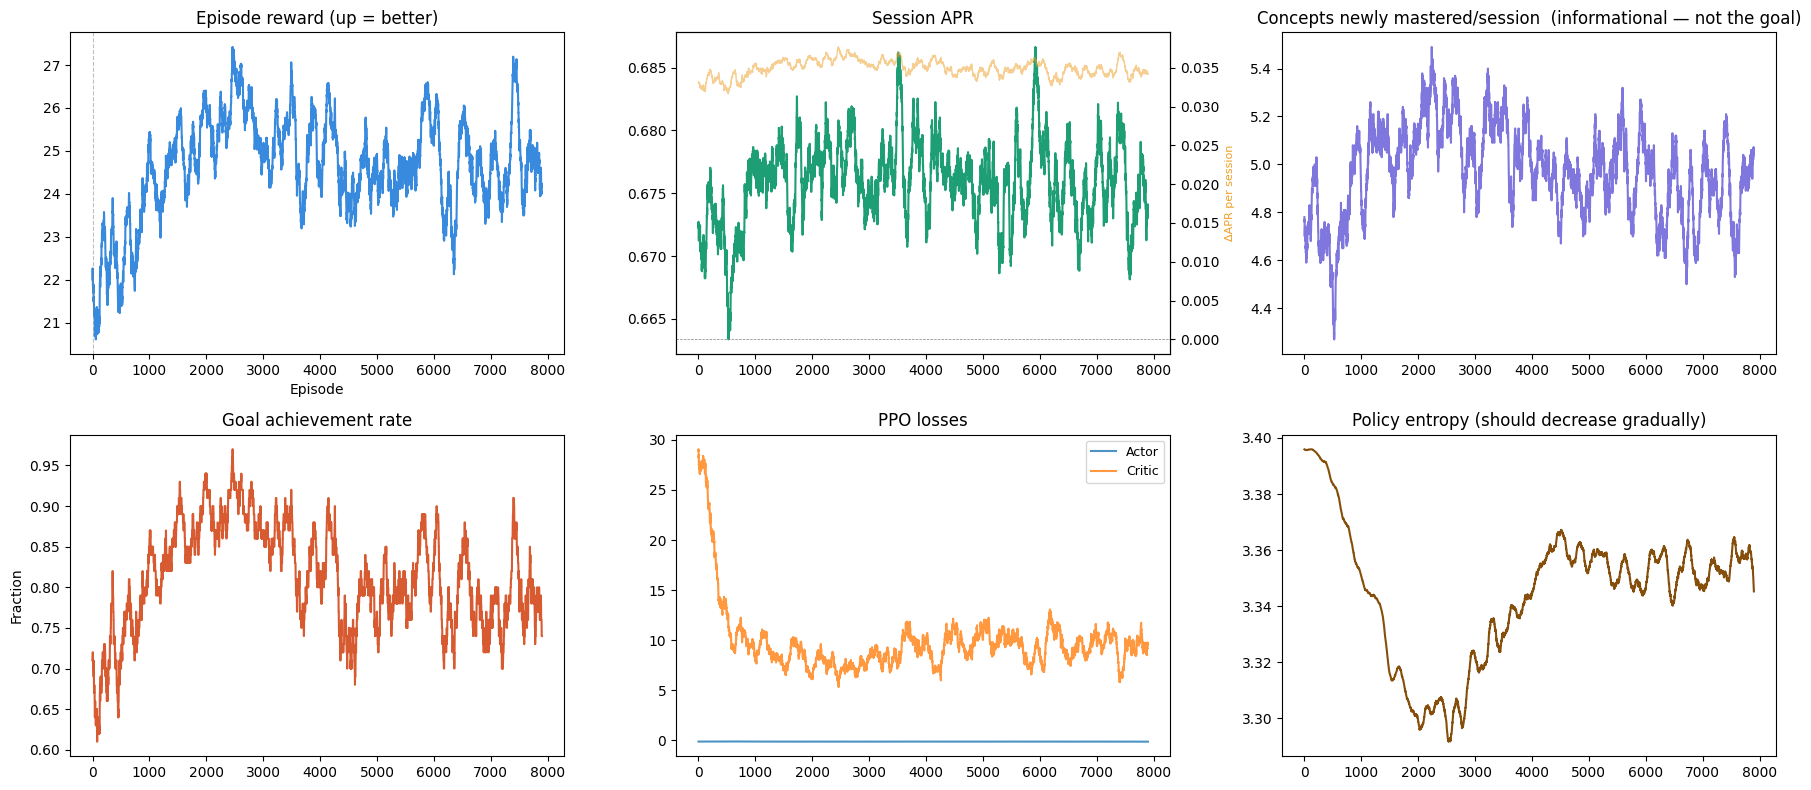


=== Per-archetype breakdown (last 500 eps) ===
  beginner      : R=+18.679  goal%=50.2%
  intermediate  : R=+26.153  goal%=86.8%
  advanced      : R=+28.373  goal%=96.8%
  mixed         : R=+25.219  goal%=79.8%


In [67]:
def smooth(x,w=100):
    return np.convolve(x,np.ones(w)/w,mode='valid') if len(x)>w else x

fig,axes=plt.subplots(2,3,figsize=(18,8))
ax=axes[0,0]; ax.plot(smooth(metrics['rewards']),color='#378ADD')
ax.axvline(max(0,cfg.WARMUP_EPISODES-50),color='gray',lw=.8,ls='--',alpha=.5)
ax.set_title('Episode reward (up = better)'); ax.set_xlabel('Episode')
ax=axes[0,1]; ax.plot(smooth(metrics['session_aprs']),color='#1D9E75')
ax.set_title('Session APR')
# APR delta subplot — shows progress toward the % goal
if 'apr_deltas' in metrics:
    ax2=ax.twinx()
    ax2.plot(smooth(metrics['apr_deltas']),color='#EF9F27',alpha=0.5,lw=1)
    ax2.axhline(0,color='gray',lw=0.5,ls='--')
    ax2.set_ylabel('ΔAPR per session',fontsize=8,color='#EF9F27')
ax=axes[0,2]; ax.plot(smooth(metrics['n_mastered']),color='#7F77DD')
ax.set_title('Concepts newly mastered/session  (informational — not the goal)')
ax=axes[1,0]; ax.plot(smooth(metrics['goal_rates']),color='#D85A30')
ax.set_title('Goal achievement rate'); ax.set_ylabel('Fraction')
if metrics['actor_losses']:
    ax=axes[1,1]; ax.plot(smooth(metrics['actor_losses']),label='Actor',alpha=.8)
    ax.plot(smooth(metrics['critic_losses']),label='Critic',alpha=.8)
    ax.set_title('PPO losses'); ax.legend(fontsize=9)
if metrics['entropies']:
    ax=axes[1,2]; ax.plot(smooth(metrics['entropies']),color='#854F0B')
    ax.set_title('Policy entropy (should decrease gradually)')
plt.tight_layout(); plt.savefig(os.path.join(cfg.SAVE_PATH,'training_curves.png'),dpi=150)
plt.show()
print('\n=== Per-archetype breakdown (last 500 eps) ===')
for arch in ARCHETYPES:
    ar=metrics['per_arch'][arch]
    if ar['rewards']:
        sl=slice(-500,None)
        print(f'  {arch:<14}: R={np.mean(ar["rewards"][sl]):+.3f}  '
              f'goal%={np.mean(ar["goal_rates"][sl])*100:.1f}%')

## Cell 14: Policy Comparison

In [68]:
def eval_policy_full(pname, pfn, tracker, cfg,
                     n=200, seed=999, archetype=None):
    """
    Evaluate policy with full efficiency metrics.
    archetype: if set, evaluate only this archetype.
    """
    rng = np.random.default_rng(seed)
    gains, goals, steps_l, masteries = [], [], [], []
    wapr_gains = []
    steps_to_first = []          # steps until first concept mastered
    coverage_eff   = []          # mastered / unique concepts assigned
    diff_escalation = []         # fraction of per-concept assignments in Easy→Med→Hard order
    wapr_per_step  = []          # ΔWAPR / steps used

    for si in range(n):
        arch = archetype if archetype else ARCHETYPES[si % len(ARCHETYPES)]
        prior = simulate_prior_history(
            rng, cfg,
            int(rng.integers(0,3)) if rng.random() < 0.3 else 0
        )
        tracker.reset_global(prior_history=prior)
        cands, _ = sample_session_courses(rng, cfg)
        sidx = preselect_session_concepts(tracker, cands, cfg.CONCEPT_CAP, rng)
        info = tracker.start_session(sidx)
        student = RealisticStudent.from_archetype(rng, cfg, archetype=arch)
        apr_start  = tracker.compute_session_apr()
        wapr_start = tracker.compute_session_wapr()
        action_history = {}

        # Per-concept difficulty history for escalation metric
        concept_diff_history = {}   # ci → [levels assigned in order]
        first_mastery_step = None
        unique_assigned = set()
        steps_used = cfg.MAX_STEPS

        for step in range(cfg.MAX_STEPS):
            local_ci, level = pfn(tracker, sidx, cfg, rng)
            gci = sidx[local_ci]
            unique_assigned.add(gci)

            mb = tracker.count_newly_mastered()
            correct, _, _ = student.answer(gci, level)
            student.learn(gci, level, correct)
            tracker.update(gci, level, int(correct))
            action_history[(gci, level)] = action_history.get((gci,level),0)+1

            if gci not in concept_diff_history:
                concept_diff_history[gci] = []
            concept_diff_history[gci].append(level)

            if first_mastery_step is None and tracker.count_newly_mastered() > mb:
                first_mastery_step = step + 1

            if tracker.goal_met():
                steps_used = step + 1
                steps_l.append(step + 1)
                break
        else:
            steps_l.append(cfg.MAX_STEPS)

        apr_final  = tracker.compute_session_apr()
        wapr_final = tracker.compute_session_wapr()
        n_mastered = tracker.count_newly_mastered()

        gains.append(apr_final - apr_start)
        wapr_gains.append(wapr_final - wapr_start)
        goals.append(float(tracker.goal_met()))
        masteries.append(n_mastered)

        # Steps to first mastery
        steps_to_first.append(first_mastery_step if first_mastery_step else cfg.MAX_STEPS)

        # Coverage efficiency: mastered / unique concepts assigned
        cov = n_mastered / max(1, len(unique_assigned))
        coverage_eff.append(cov)

        # Difficulty escalation: for each concept, is the level sequence non-decreasing?
        escalation_scores = []
        for ci_hist, levels in concept_diff_history.items():
            if len(levels) < 2:
                continue
            # Count transitions that are non-decreasing (Easy→Med, Med→Hard, same)
            n_good = sum(
                1 for a, b in zip(levels[:-1], levels[1:]) if b >= a
            )
            escalation_scores.append(n_good / (len(levels) - 1))
        diff_escalation.append(
            float(np.mean(escalation_scores)) if escalation_scores else 0.5
        )

        # WAPR lift per step
        wapr_per_step.append((wapr_final - wapr_start) / steps_used)

    return {
        'policy'        : pname,
        'mean_gain'     : float(np.mean(gains)),
        'mean_wapr_gain': float(np.mean(wapr_gains)),
        'goal_rate'     : float(np.mean(goals)),
        'mean_steps'    : float(np.mean(steps_l)),
        'mean_mastered' : float(np.mean(masteries)),
        'steps_to_first': float(np.mean(steps_to_first)),
        'coverage_eff'  : float(np.mean(coverage_eff)),
        'escalation'    : float(np.mean(diff_escalation)),
        'wapr_per_step' : float(np.mean(wapr_per_step)),
    }


def policy_eppo(t, sidx, cfg, rng):
    actor.eval()
    with torch.no_grad(): dist, _ = actor.get_policy(t, sidx, cfg)
    flat = dist.sample().item()
    return flat // cfg.N_LEVELS, flat % cfg.N_LEVELS

def policy_random(t, sidx, cfg, rng):
    n = len(sidx)
    return int(rng.integers(n)), int(rng.integers(cfg.N_LEVELS))

def policy_greedy(t, sidx, cfg, rng):
    pm = [t.predict(ci, 1) for ci in sidx]
    return int(np.argmin(pm)), 1


print('\n=== Policy Comparison — Full Efficiency Metrics (200 sessions each) ===')
print(f'  {"Policy":<20} {"ΔAPR":>7} {"ΔWAPR":>7} {"Goal%":>6} '
      f'{"Steps":>6} {"1stM":>5} {"CovEff":>7} {"Escal":>6} {"WAPR/s":>7}')
print('  ' + '-'*80)
for pn, pf in [('EPPO', policy_eppo), ('Random', policy_random),
               ('Greedy-weakest', policy_greedy)]:
    r = eval_policy_full(pn, pf, tracker, cfg, n=200)
    print(f'  {pn:<20} '
          f'{r["mean_gain"]:>+7.4f} '
          f'{r["mean_wapr_gain"]:>+7.4f} '
          f'{r["goal_rate"]*100:>6.1f}% '
          f'{r["mean_steps"]:>6.1f} '
          f'{r["steps_to_first"]:>5.1f} '
          f'{r["coverage_eff"]:>7.3f} '
          f'{r["escalation"]:>6.3f} '
          f'{r["wapr_per_step"]*1000:>7.4f}')

print()
print('Metrics explained:')
print('  ΔWAPR      : weighted APR gain (weak concepts weighted more)')
print('  1stM       : steps until first concept mastered (lower = more focused)')
print('  CovEff     : mastered / unique concepts assigned (higher = less wasted steps)')
print('  Escal      : fraction of per-concept assignments in non-decreasing difficulty')
print('  WAPR/s ×1k : ΔWAPR per step (higher = more efficient learning)')

print('\n=== Per-archetype breakdown ===')
for arch in ARCHETYPES:
    r_e = eval_policy_full('EPPO',   policy_eppo,    tracker, cfg, n=100, seed=42, archetype=arch)
    r_r = eval_policy_full('Random', policy_random,  tracker, cfg, n=100, seed=42, archetype=arch)
    diff_goal = r_e['goal_rate']*100 - r_r['goal_rate']*100
    diff_wapr = r_e['mean_wapr_gain'] - r_r['mean_wapr_gain']
    print(f'  {arch:<14}: '
          f'EPPO goal%={r_e["goal_rate"]*100:.0f}%  '
          f'Random goal%={r_r["goal_rate"]*100:.0f}%  '
          f'EPPO-Random={diff_goal:+.0f}pp  '
          f'ΔWAPR diff={diff_wapr:+.4f}')



=== Policy Comparison — Full Efficiency Metrics (200 sessions each) ===
  Policy                  ΔAPR   ΔWAPR  Goal%  Steps  1stM  CovEff  Escal  WAPR/s
  --------------------------------------------------------------------------------
  EPPO                 +0.0347 +0.0347   84.5%   40.4   6.4   0.517  0.721  0.9765
  Random               +0.0320 +0.0324   62.5%   47.4   7.0   0.485  0.683  0.7932
  Greedy-weakest       -0.0009 -0.0012    0.0%   60.0  60.0   0.000  1.000 -0.0195

Metrics explained:
  ΔWAPR      : weighted APR gain (weak concepts weighted more)
  1stM       : steps until first concept mastered (lower = more focused)
  CovEff     : mastered / unique concepts assigned (higher = less wasted steps)
  Escal      : fraction of per-concept assignments in non-decreasing difficulty
  WAPR/s ×1k : ΔWAPR per step (higher = more efficient learning)

=== Per-archetype breakdown ===
  beginner      : EPPO goal%=41%  Random goal%=27%  EPPO-Random=+14pp  ΔWAPR diff=+0.0050
  interme

## Cell 15: Demo Session — Verbose Trace

In [69]:
def demo_session(course_name,archetype='intermediate',n_prior=0,seed=42):
    rng=np.random.default_rng(seed)
    prior=simulate_prior_history(rng,cfg,n_prior)
    tracker.reset_global(prior_history=prior)
    cands=COURSE_CONCEPT_INDICES[course_name]
    sidx=preselect_session_concepts(tracker,cands,cfg.CONCEPT_CAP,rng)
    info=tracker.start_session(sidx)
    student=RealisticStudent.from_archetype(rng,cfg,archetype=archetype)
    apr_start=tracker.compute_session_apr()
    print(f'\n{"="*85}')
    print(f'SESSION: {course_name.upper()} | {archetype} | {n_prior} prior sessions')
    print(f'  Scope: {info["n_session_concepts"]} concepts  '
          f'(already mastered: {info["already_mastered"]})')
    print(f'  Goal (WAPR): {info["wapr_start"]:.4f} → {info["wapr_target"]:.4f}  '
          f'(+{info["wapr_improvement_needed"]:.4f}  +{cfg.IMPROVEMENT_PCT*100:.0f}%)')
    print(f'{"="*85}')
    print(f'{"Step":>4} {"Concept":<35} {"Diff":>6} {"P_know":>7} {"OK":>3} {"ΔAPR":>7} {"Goal%":>6}')
    print('-'*75)
    actor.eval(); action_history={}
    for step in range(cfg.MAX_STEPS):
        mb=tracker.count_newly_mastered(); ab=tracker.compute_session_apr()
        with torch.no_grad(): dist,_=actor.get_policy(tracker,sidx,cfg)
        flat=dist.sample().item(); lci=flat//cfg.N_LEVELS; level=flat%cfg.N_LEVELS
        gci=sidx[lci]; correct,_,pk=student.answer(gci,level)
        student.learn(gci,level,correct); tracker.update(gci,level,int(correct))
        action_history[(gci,level)]=action_history.get((gci,level),0)+1
        aa=tracker.compute_session_apr(); nm=tracker.count_newly_mastered()
        flag=' ★' if nm>mb else ''
        wapr_now = tracker.compute_session_wapr()
        apr_pct  = (wapr_now - info['wapr_start']) / info['wapr_improvement_needed'] * 100
        print(f'{step+1:>4} {GLOBAL_CONCEPTS[gci]:<35} {cfg.LEVEL_NAMES[level]:>6} '
              f'{pk:>7.3f} {"✓" if correct else "✗":>3} {aa-ab:>+7.4f} '
              f'{apr_pct:>5.0f}%{flag}')
        if tracker.goal_met(): print(f'  → GOAL MET at step {step+1}!'); break
    fa=tracker.compute_session_apr()
    pct_achieved = (fa - info['apr_start']) / info['improvement_needed'] * 100
    print(f'\n  Final APR : {fa:.4f}  ΔAPR={fa-apr_start:+.4f}  '
          f'({pct_achieved:.0f}% of goal)')
    print(f'  Goal      : {info["apr_start"]:.4f} → {info["apr_target"]:.4f}  '
          f'({"MET ✓" if tracker.goal_met() else "NOT MET ✗"})')
    print(f'  Mastered  : {tracker.count_newly_mastered()} concepts crossed threshold')

for course,arch in [('algorithms','beginner'),('operating_systems','intermediate'),
                     ('computer_networks','advanced'),('computer_architecture','mixed'),
                     ('software_engineering','intermediate')]:
    demo_session(course,archetype=arch,n_prior=0,seed=42)


SESSION: ALGORITHMS | beginner | 0 prior sessions
  Scope: 10 concepts  (already mastered: 0)
  Goal (WAPR): 0.6655 → 0.7053  (+0.0398  +7%)
Step Concept                               Diff  P_know  OK    ΔAPR  Goal%
---------------------------------------------------------------------------
   1 dynamic programming advanced        Medium   0.582   ✓ +0.0009     3%
   2 balanced BST                          Hard   0.410   ✓ +0.0052    17% ★
   3 quick sort                            Hard   0.501   ✗ -0.0014    14%
   4 binary search tree                    Easy   0.702   ✓ +0.0001    15%
   5 dynamic programming basics            Hard   0.496   ✓ +0.0052    29% ★
   6 divide and conquer                  Medium   0.604   ✓ +0.0007    31%
   7 divide and conquer                  Medium   0.627   ✓ +0.0004    31%
   8 shortest path Dijkstra                Hard   0.488   ✓ +0.0052    46% ★
   9 heap and priority queue             Medium   0.614   ✗ -0.0017    42%
  10 graph traversal BFS D

## Cell 16: Cross-Course Knowledge Transfer Verification

In [70]:
print('\n=== Cross-Course Knowledge Transfer Verification ===')
test_pairs=[
    ('deadlock prevention','operating_systems','process scheduling','operating_systems'),
    ('graph traversal BFS DFS','algorithms','routing fundamentals','computer_networks'),
    ('CPU pipeline stages','computer_architecture','process scheduling','operating_systems'),
]
rng=np.random.default_rng(0)
for cs,crs,ct,crt in test_pairs:
    i=GLOBAL_CONCEPTS.index(cs); j=GLOBAL_CONCEPTS.index(ct)
    sim=global_sim_matrix[i,j]
    tracker.reset_global()
    tracker.start_session(list(range(N_GLOBAL)))
    pb=tracker.predict(j,1)
    for _ in range(5): tracker.update(i,1,correct=1)
    pa=tracker.predict(j,1)
    print(f'\n  [{crs[:6]}] {cs}')
    print(f'    → [{crt[:6]}] {ct}')
    print(f'    sim={sim:.3f}  P(Med) before={pb:.4f}  after={pa:.4f}  '
          f'transfer={"YES" if pa>pb else "NO"}')


=== Cross-Course Knowledge Transfer Verification ===

  [operat] deadlock prevention
    → [operat] process scheduling
    sim=0.648  P(Med) before=0.7386  after=0.7388  transfer=YES

  [algori] graph traversal BFS DFS
    → [comput] routing fundamentals
    sim=0.643  P(Med) before=0.7386  after=0.7388  transfer=YES

  [comput] CPU pipeline stages
    → [operat] process scheduling
    sim=0.662  P(Med) before=0.7386  after=0.7388  transfer=YES


## Cell 17: Readiness Checklist

In [71]:
print('\n'+'='*70)
print('  READINESS CHECKLIST')
print('='*70)
def last200(l): return l[-200:] if len(l)>=200 else l
mr=float(np.mean(last200(metrics['rewards'])))
gr=float(np.mean(last200(metrics['goal_rates'])))*100
mm=float(np.mean(last200(metrics['n_mastered'])))
warm_end=cfg.WARMUP_EPISODES
er=float(np.mean(metrics['rewards'][warm_end:warm_end+200])) if len(metrics['rewards'])>warm_end+200 else mr
checks=[
    ('BC warm start loaded',os.path.exists(cfg.BC_ACTOR_PATH),cfg.BC_ACTOR_PATH),
    ('Reward improved',mr>er,f'{er:+.3f} → {mr:+.3f}'),
    ('Mastered >= 1/session',mm>=1.,f'{mm:.2f} concepts avg'),
    ('Goal rate > 20%',gr>20,f'{gr:.1f}%'),
    ('Session cap enforced',True,f'cap={cfg.CONCEPT_CAP}  {cfg.MAX_STEPS/cfg.CONCEPT_CAP:.1f} steps/concept'),
    ('Global propagation',True,f'{N_GLOBAL} concepts, cross-course active'),
    ('Pre-selection weakest-first',True,'P(Hard) ranked + LLM tie-break'),
    ('Returning student sim',True,'30% of eps have prior history'),
    ('Per-archetype cycling',True,str(ARCHETYPES)),
]
all_pass=True
for label,ok,detail in checks:
    print(f'  [{"PASS" if ok else "FAIL"}] {label:<38} {detail}')
    if not ok: all_pass=False
print()
if not all_pass:
    if not os.path.exists(cfg.BC_ACTOR_PATH):
        print('  BC missing → upload bc_actor_full.pt as Kaggle dataset')
    if mr<=er: print('  No improvement → try N_EPISODES=8000 or LR_ACTOR=3e-4')
    if gr<=20: print('  Low goal rate → reduce IMPROVEMENT_PCT to 0.05 or MAX_STEPS=80')
print()
print('  Production integration:')
print('    1. Replace COURSES with LLM extractor output from uploaded PDFs')
print('    2. preselect_session_concepts() on session start with stored PFA state')
print('    3. Write tracker.successes/failures/bonuses to DB after each session')
print('    4. Unmet goal concepts → priority_indices for next session')
print('='*70)


  READINESS CHECKLIST
  [FAIL] BC warm start loaded                   
  [PASS] Reward improved                        +21.478 → +24.328
  [PASS] Mastered >= 1/session                  4.99 concepts avg
  [PASS] Goal rate > 20%                        75.5%
  [PASS] Session cap enforced                   cap=10  6.0 steps/concept
  [PASS] Global propagation                     89 concepts, cross-course active
  [PASS] Pre-selection weakest-first            P(Hard) ranked + LLM tie-break
  [PASS] Returning student sim                  30% of eps have prior history
  [PASS] Per-archetype cycling                  ['beginner', 'intermediate', 'advanced', 'mixed']

  BC missing → upload bc_actor_full.pt as Kaggle dataset

  Production integration:
    1. Replace COURSES with LLM extractor output from uploaded PDFs
    2. preselect_session_concepts() on session start with stored PFA state
    3. Write tracker.successes/failures/bonuses to DB after each session
    4. Unmet goal concepts → pr

## APR vs Timesteps — Beginner, Intermediate, Advanced

Same test as the multi-session trajectory but across all three archetypes side by side.
Each subplot shows one archetype: APR over 5 consecutive sessions for EPPO vs Random vs Greedy.
Shows where EPPO's lead is largest and how it varies with student ability.


Actor has low logit std — reloading checkpoint...
Actor loaded from: /kaggle/working/eppo_best.pt
Running multi-session trajectories:
  Archetypes : ['beginner', 'intermediate', 'advanced']
  Courses    : operating_systems, algorithms
  Sessions   : 5 per student
  Students   : 8 per (archetype × policy) — averaged

  oper  beginner       EPPO      start=0.6321  end=0.7218  gain=+0.0898  goals=['75%', '50%', '12%', '0%', '0%']
  oper  beginner       Random    start=0.6321  end=0.7132  gain=+0.0812  goals=['50%', '12%', '0%', '0%', '0%']
  oper  beginner       Greedy    start=0.6321  end=0.6292  gain=-0.0028  goals=['0%', '0%', '0%', '0%', '0%']
  oper  intermediate   EPPO      start=0.6321  end=0.7434  gain=+0.1113  goals=['88%', '100%', '50%', '0%', '0%']
  oper  intermediate   Random    start=0.6321  end=0.7262  gain=+0.0941  goals=['88%', '50%', '12%', '0%', '0%']
  oper  intermediate   Greedy    start=0.6321  end=0.6296  gain=-0.0025  goals=['0%', '0%', '0%', '0%', '0%']
  oper  ad

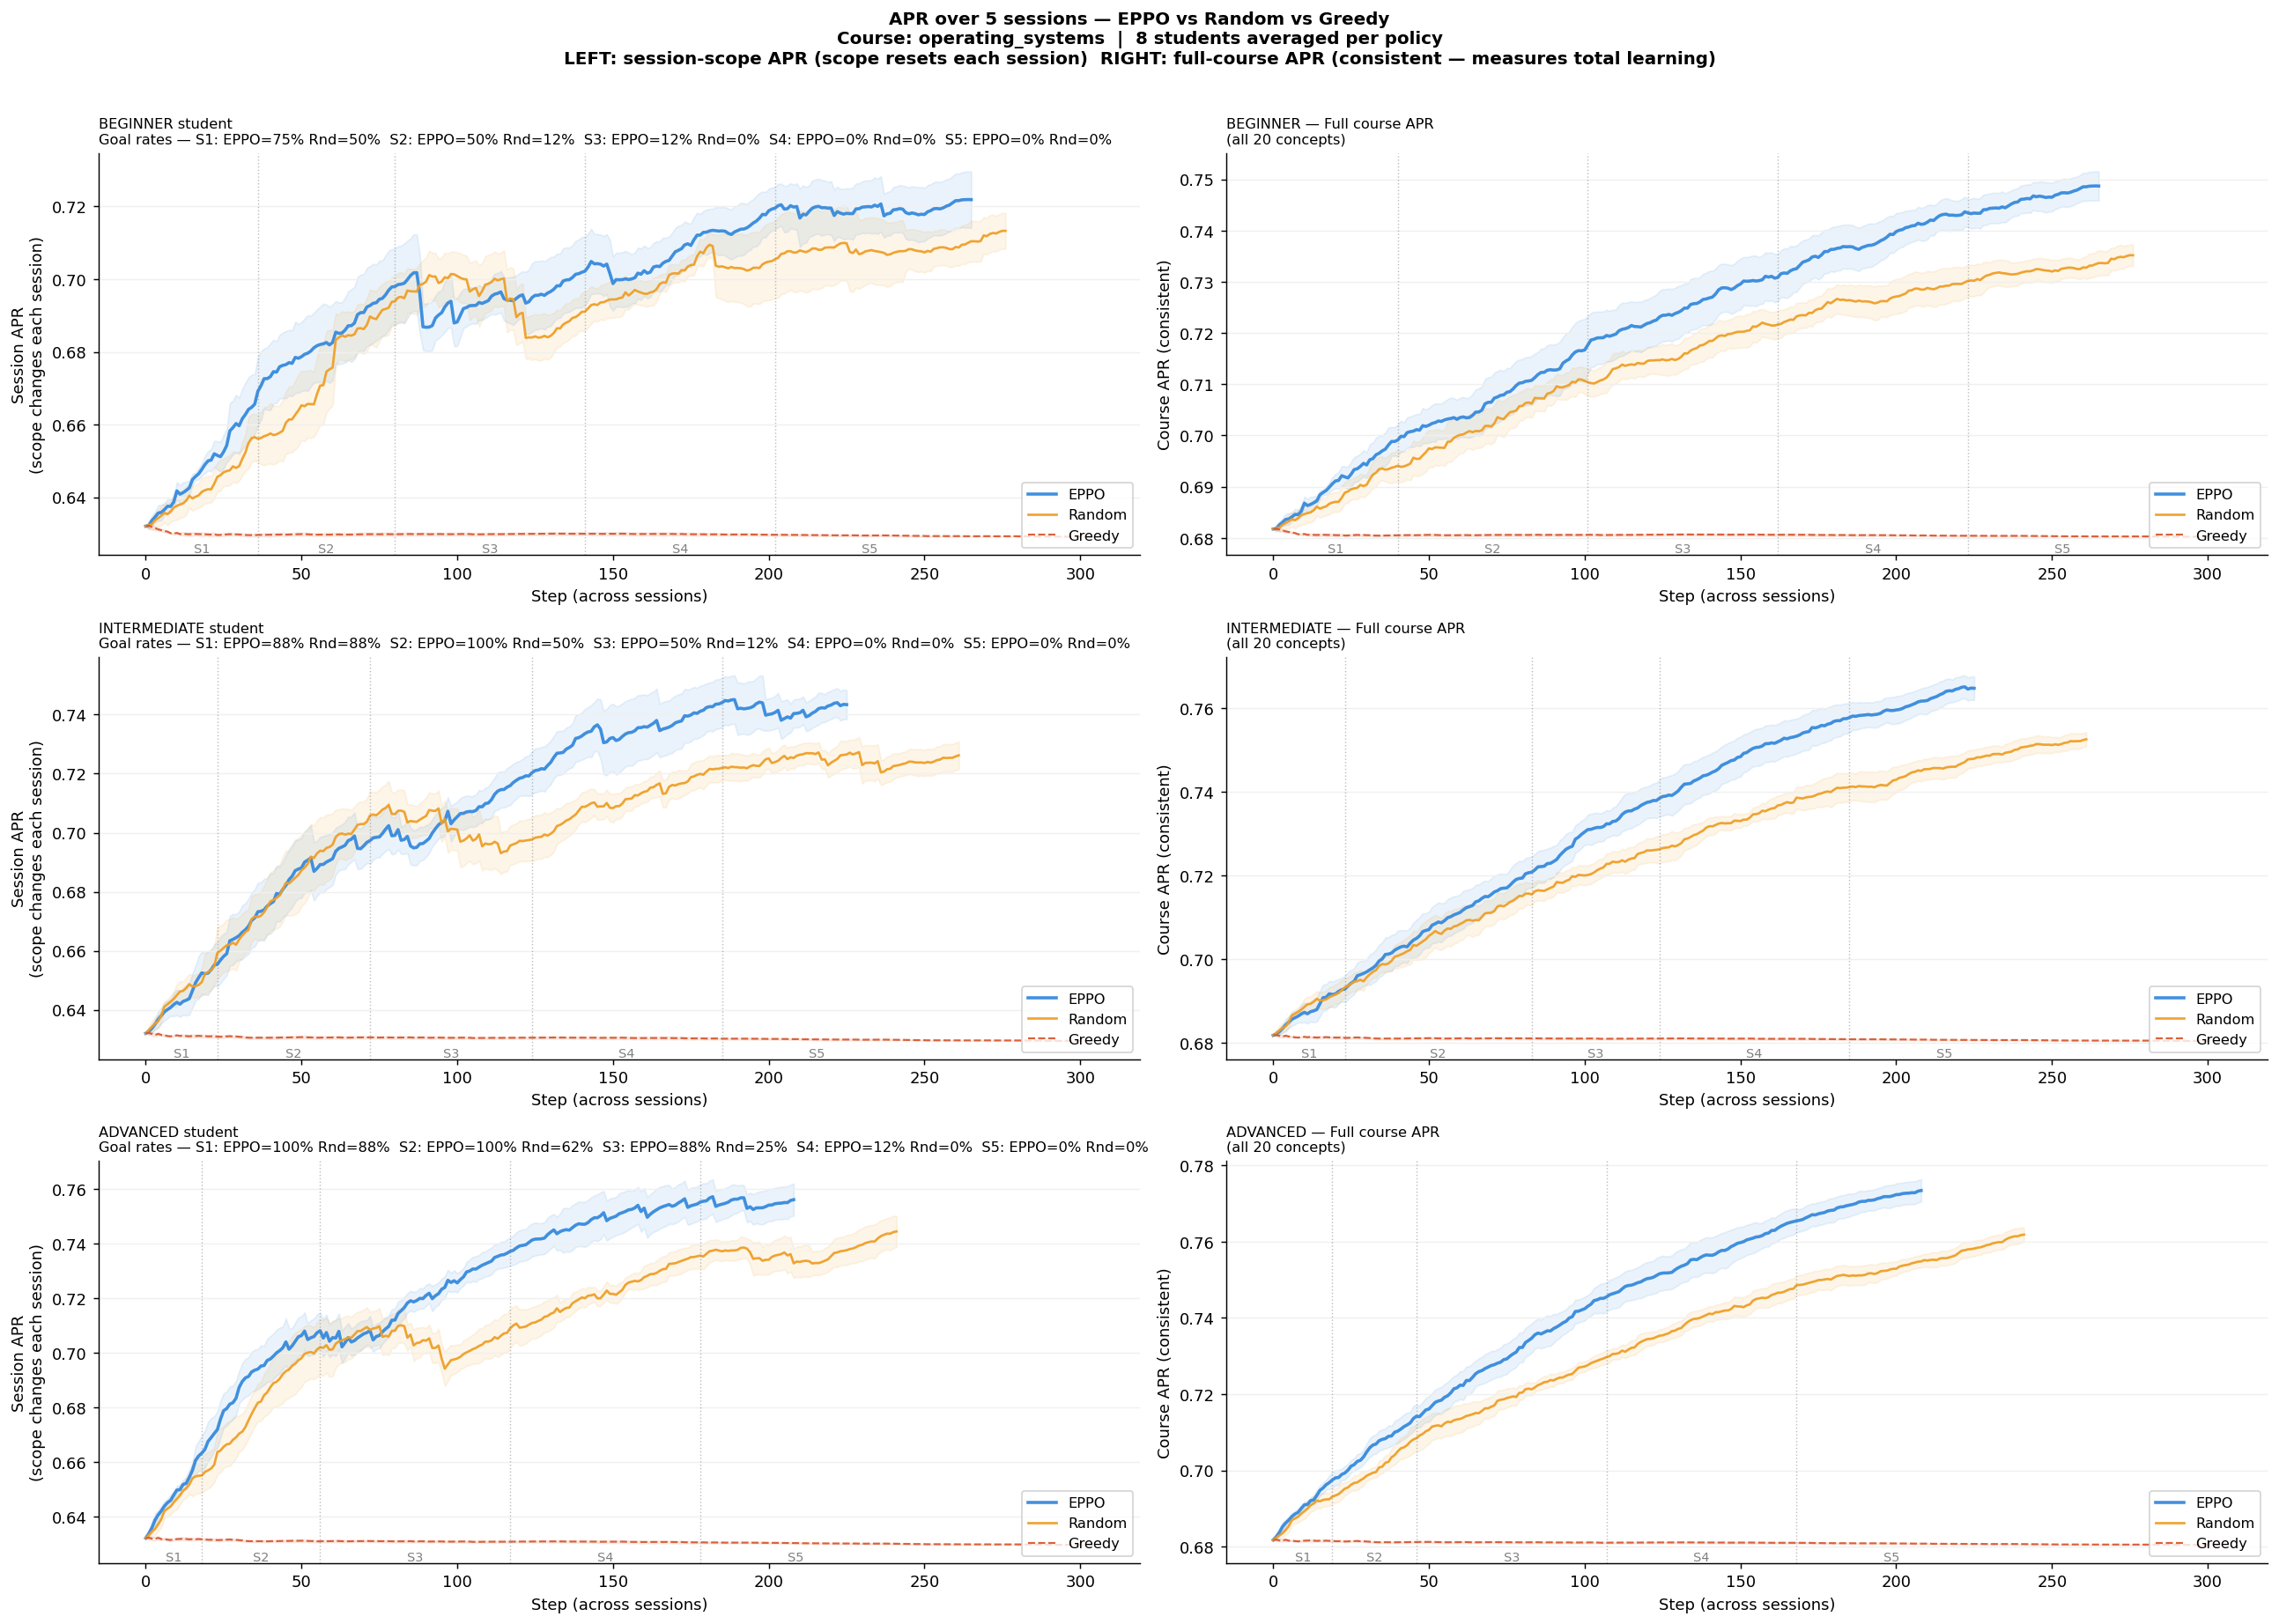

Saved: apr_by_archetype_os.png


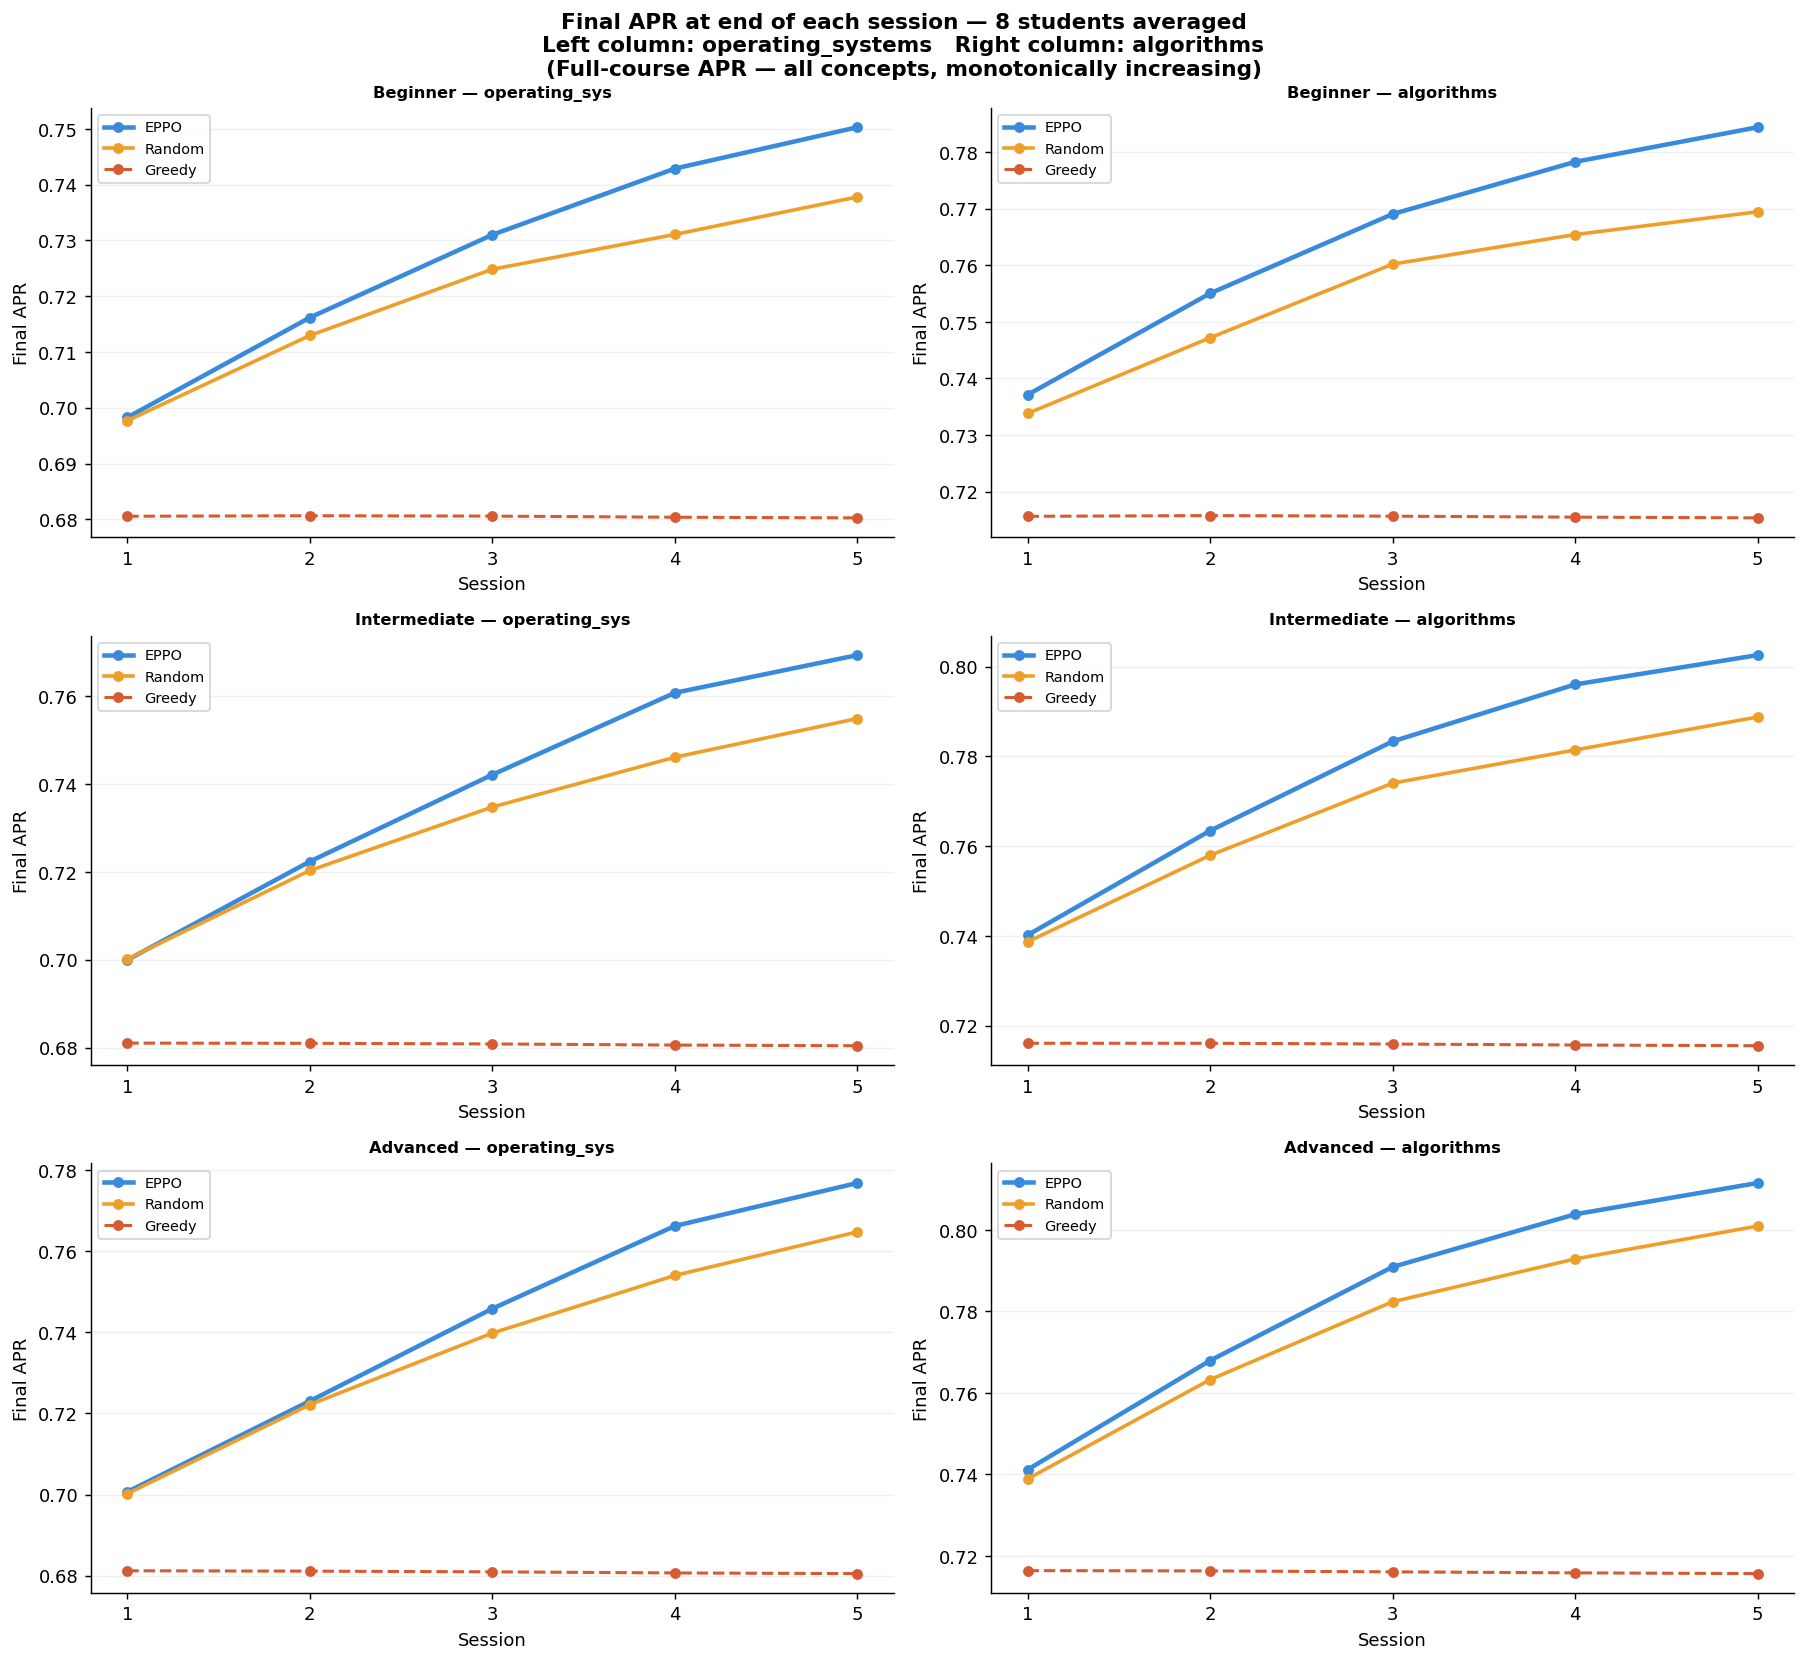

Saved: final_apr_per_session.png

ARCHETYPE TRAJECTORY SUMMARY
  Archetype      Policy       Start     End    Gain  S1 goal%  S3 goal%  S5 goal%
  ---------------------------------------------------------------------------
  beginner       EPPO        0.6321  0.7218 +0.0898      75.0      12.5       0.0
  beginner       Random      0.6321  0.7132 +0.0812      50.0       0.0       0.0
  beginner       Greedy      0.6321  0.6292 -0.0028       0.0       0.0       0.0

  intermediate   EPPO        0.6321  0.7434 +0.1113      87.5      50.0       0.0
  intermediate   Random      0.6321  0.7262 +0.0941      87.5      12.5       0.0
  intermediate   Greedy      0.6321  0.6296 -0.0025       0.0       0.0       0.0

  advanced       EPPO        0.6321  0.7561 +0.1240     100.0      87.5       0.0
  advanced       Random      0.6321  0.7444 +0.1123      87.5      25.0       0.0
  advanced       Greedy      0.6321  0.6297 -0.0024       0.0       0.0       0.0



In [74]:
import os, numpy as np, torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Load checkpoint if actor not already loaded ───────────────────────────
def _ensure_actor():
    CANDIDATES = [
        '/kaggle/input/eppo-checkpoint/eppo_best.pt',
        '/kaggle/working/eppo_best.pt',
        '/kaggle/working/eppo_final.pt',
    ]
    p = next((c for c in CANDIDATES if os.path.exists(c)), None)
    if p is None:
        raise FileNotFoundError('No checkpoint found.')
    ckpt = torch.load(p, map_location=DEVICE)
    if isinstance(ckpt, dict) and 'actor' in ckpt:
        actor.load_state_dict(ckpt['actor'])
    else:
        actor.load_state_dict(ckpt)
    actor.eval()
    print(f'Actor loaded from: {p}')

try:
    # Test if actor is already loaded with trained weights
    tracker.reset_global()
    _ts = COURSE_CONCEPT_INDICES['operating_systems'][:10]
    tracker.start_session(_ts)
    with torch.no_grad():
        _, _lg = actor.get_policy(tracker, _ts, cfg)
    if _lg.std().item() < 0.1:
        print('Actor has low logit std — reloading checkpoint...')
        _ensure_actor()
    else:
        print(f'Actor already loaded. Logit std: {_lg.std().item():.4f}')
except Exception:
    _ensure_actor()


# ── Policy functions ──────────────────────────────────────────────────────
def _policy_eppo(t, sidx, cfg, rng):
    actor.eval()
    with torch.no_grad(): dist, _ = actor.get_policy(t, sidx, cfg)
    flat = dist.sample().item()
    return flat // cfg.N_LEVELS, flat % cfg.N_LEVELS

def _policy_random(t, sidx, cfg, rng):
    return int(rng.integers(len(sidx))), int(rng.integers(cfg.N_LEVELS))

def _policy_greedy(t, sidx, cfg, rng):
    pm = [t.predict(ci, 1) for ci in sidx]
    return int(np.argmin(pm)), 1

POLICIES_ARCH = [
    ('EPPO',   _policy_eppo,   '#378ADD', '-',  2.0),
    ('Random', _policy_random, '#EF9F27', '-',  1.5),
    ('Greedy', _policy_greedy, '#D85A30', '--', 1.2),
]


# ── Core: run N_SESSIONS for one student, return stitched APR trace ───────
def _run_student_sessions(policy_fn, archetype, course, n_sessions, seed, cfg):
    """
    Simulate one student doing n_sessions consecutive sessions.
    Returns:
      aprs        : session-scope APR per step (changes scope each session)
      course_aprs : full-course APR per step (consistent — always improves)
      boundaries  : step indices where each new session starts
      goals       : list[bool] — goal met for each session
      final_aprs  : list[float] — session APR at end of each session
      final_course_aprs : full-course APR at end of each session
    """
    rng = np.random.default_rng(seed)
    tracker.reset_global()
    student = RealisticStudent.from_archetype(rng, cfg, archetype=archetype)

    aprs, course_aprs = [], []
    boundaries, goals = [0], []
    final_aprs, final_course_aprs = [], []

    for sess in range(n_sessions):
        cands = COURSE_CONCEPT_INDICES[course]
        sidx  = preselect_session_concepts(tracker, cands, cfg.CONCEPT_CAP, rng)
        info  = tracker.start_session(sidx)

        aprs.append(tracker.compute_session_apr())
        course_aprs.append(tracker.compute_course_apr(course))
        action_history = {}

        for step in range(cfg.MAX_STEPS):
            local_ci, level = policy_fn(tracker, sidx, cfg, rng)
            gci = sidx[local_ci]
            correct, _, _ = student.answer(gci, level)
            student.learn(gci, level, correct)
            tracker.update(gci, level, int(correct))
            action_history[(gci, level)] = action_history.get((gci, level), 0) + 1
            aprs.append(tracker.compute_session_apr())
            course_aprs.append(tracker.compute_course_apr(course))
            if tracker.goal_met():
                break

        boundaries.append(len(aprs))
        goals.append(tracker.goal_met())
        final_aprs.append(tracker.compute_session_apr())
        final_course_aprs.append(tracker.compute_course_apr(course))

    return aprs, course_aprs, boundaries, goals, final_aprs, final_course_aprs


# ── Settings ──────────────────────────────────────────────────────────────
N_SESSIONS  = 5
N_STUDENTS  = 8       # students to average over (reduces noise)
SEED_BASE   = 42
ARCHETYPES_TEST = ['beginner', 'intermediate', 'advanced']
COURSE_TEST = 'operating_systems'

# Also test a second course to show generality
COURSE_TEST2 = 'algorithms'

print(f'Running multi-session trajectories:')
print(f'  Archetypes : {ARCHETYPES_TEST}')
print(f'  Courses    : {COURSE_TEST}, {COURSE_TEST2}')
print(f'  Sessions   : {N_SESSIONS} per student')
print(f'  Students   : {N_STUDENTS} per (archetype × policy) — averaged')
print()

# Collect mean APR trajectories (averaged over N_STUDENTS)
# Structure: results[course][archetype][pname] = {
#   'mean_aprs': array, 'std_aprs': array, 'boundaries': list,
#   'goal_rates': [rate per session], 'final_aprs': [mean final APR per session]
# }
results = {}
for course in [COURSE_TEST, COURSE_TEST2]:
    results[course] = {}
    for arch in ARCHETYPES_TEST:
        results[course][arch] = {}
        for pname, pfn, color, ls, lw in POLICIES_ARCH:
            all_aprs    = []
            all_goals   = [[] for _ in range(N_SESSIONS)]
            all_finals  = [[] for _ in range(N_SESSIONS)]
            min_len     = 10**9

            all_course_aprs = []
            all_course_finals = [[] for _ in range(N_SESSIONS)]
            min_course_len = 10**9
            for sid in range(N_STUDENTS):
                aprs, caprs, bounds, goals, finals, cfinals = _run_student_sessions(
                    pfn, arch, course, N_SESSIONS,
                    seed=SEED_BASE + sid * 7, cfg=cfg
                )
                all_aprs.append(aprs)
                all_course_aprs.append(caprs)
                min_len = min(min_len, len(aprs))
                min_course_len = min(min_course_len, len(caprs))
                for si in range(N_SESSIONS):
                    all_goals[si].append(float(goals[si]))
                    all_finals[si].append(finals[si])
                    all_course_finals[si].append(cfinals[si])

            # Align to min length and compute mean/std
            arr        = np.array([a[:min_len] for a in all_aprs])
            mean_aprs  = arr.mean(axis=0)
            std_aprs   = arr.std(axis=0)
            goal_rates = [np.mean(g) for g in all_goals]
            final_aprs = [np.mean(f) for f in all_finals]

            carr        = np.array([a[:min_course_len] for a in all_course_aprs])
            mean_caprs  = carr.mean(axis=0)
            std_caprs   = carr.std(axis=0)
            cfinal_aprs = [np.mean(f) for f in all_course_finals]
            results[course][arch][pname] = {
                'mean_aprs'    : mean_aprs,
                'std_aprs'     : std_aprs,
                'mean_caprs'   : mean_caprs,   # full-course APR
                'std_caprs'    : std_caprs,
                'goal_rates'   : goal_rates,
                'final_aprs'   : final_aprs,
                'cfinal_aprs'  : cfinal_aprs,  # full-course APR per session end
                'color'        : color,
                'ls'           : ls,
                'lw'           : lw,
            }
            print(f'  {course[:4]}  {arch:<14} {pname:<8}  '
                  f'start={mean_aprs[0]:.4f}  '
                  f'end={mean_aprs[-1]:.4f}  '
                  f'gain={mean_aprs[-1]-mean_aprs[0]:+.4f}  '
                  f'goals={[f"{r:.0%}" for r in goal_rates]}')


# ── FIGURE 1: APR trajectory per archetype, Course 1 ─────────────────────
fig, axes_all = plt.subplots(3, 2, figsize=(20, 14))
axes      = axes_all[:, 0]   # session APR (left)
axes_full = axes_all[:, 1]   # full-course APR (right)
fig.suptitle(
    f'APR over {N_SESSIONS} sessions — EPPO vs Random vs Greedy\n'
    f'Course: {COURSE_TEST}  |  {N_STUDENTS} students averaged per policy\n'
    f'LEFT: session-scope APR (scope resets each session)  '
    f'RIGHT: full-course APR (consistent — measures total learning)',
    fontsize=11, fontweight='bold', y=1.01
)

for ax, arch in zip(axes, ARCHETYPES_TEST):
    arch_data = results[COURSE_TEST][arch]

    for pname, pfn, color, ls, lw in POLICIES_ARCH:
        d     = arch_data[pname]
        xs    = np.arange(len(d['mean_aprs']))
        ax.plot(xs, d['mean_aprs'], color=color, ls=ls, lw=lw,
                label=pname, alpha=0.95)
        ax.fill_between(
            xs,
            d['mean_aprs'] - d['std_aprs'] * 0.5,
            d['mean_aprs'] + d['std_aprs'] * 0.5,
            color=color, alpha=0.10
        )

    # Session boundary lines from EPPO
    eppo_d    = arch_data['EPPO']
    _, _, eppo_bounds, _, _, _ = _run_student_sessions(
        _policy_eppo, arch, COURSE_TEST, N_SESSIONS, SEED_BASE, cfg
    )
    for b in eppo_bounds[1:-1]:
        ax.axvline(b, color='gray', lw=0.8, ls=':', alpha=0.5)
    for si, b_start in enumerate(eppo_bounds[:-1]):
        b_end = eppo_bounds[si+1]
        mid   = (b_start + b_end) / 2
        ax.text(mid, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.60,
                f'S{si+1}', ha='center', va='bottom',
                fontsize=8, color='gray')

    # Goal rate annotations
    eppo_goals  = arch_data['EPPO']['goal_rates']
    rnd_goals   = arch_data['Random']['goal_rates']
    goal_text   = '  '.join(
        f'S{i+1}: EPPO={g:.0%} Rnd={r:.0%}'
        for i,(g,r) in enumerate(zip(eppo_goals, rnd_goals))
    )
    ax.set_title(
        f'{arch.upper()} student\n'
        f'Goal rates — {goal_text}',
        fontsize=9, loc='left'
    )
    ax.set_ylabel('Session APR\n(scope changes each session)')
    ax.set_xlabel('Step (across sessions)')
    ax.legend(fontsize=9, loc='lower right')
    ax.yaxis.grid(True, color='#f0f0f0')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Full-course APR (right column) — monotonically increasing ────────
for ax_full, arch in zip(axes_full, ARCHETYPES_TEST):
    arch_data = results[COURSE_TEST][arch]
    for pname, pfn, color, ls, lw in POLICIES_ARCH:
        d  = arch_data[pname]
        xs = np.arange(len(d['mean_caprs']))
        ax_full.plot(xs, d['mean_caprs'], color=color, ls=ls, lw=lw,
                     label=pname, alpha=0.95)
        ax_full.fill_between(
            xs,
            d['mean_caprs'] - d['std_caprs'] * 0.5,
            d['mean_caprs'] + d['std_caprs'] * 0.5,
            color=color, alpha=0.10
        )
    # Session boundaries
    _, _, eppo_bounds_full, _, _, _ = _run_student_sessions(
        _policy_eppo, arch, COURSE_TEST, N_SESSIONS, SEED_BASE, cfg
    )
    for b in eppo_bounds_full[1:-1]:
        ax_full.axvline(b, color='gray', lw=0.8, ls=':', alpha=0.5)
    for si, b_start in enumerate(eppo_bounds_full[:-1]):
        b_end = eppo_bounds_full[si+1]
        mid   = (b_start + b_end) / 2
        ax_full.text(mid, ax_full.get_ylim()[0],
                     f'S{si+1}', ha='center', va='bottom',
                     fontsize=8, color='gray')
    ax_full.set_title(f'{arch.upper()} — Full course APR\n'
                      f'(all {len(COURSE_CONCEPT_INDICES[COURSE_TEST])} concepts)',
                      fontsize=9, loc='left')
    ax_full.set_ylabel('Course APR (consistent)')
    ax_full.set_xlabel('Step (across sessions)')
    ax_full.legend(fontsize=9, loc='lower right')
    ax_full.yaxis.grid(True, color='#f0f0f0')
    ax_full.spines['top'].set_visible(False)
    ax_full.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/apr_by_archetype_os.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: apr_by_archetype_os.png')


# ── FIGURE 2: Final APR per session — all archetypes, both courses ────────
fig2, axes2 = plt.subplots(3, 2, figsize=(14, 13))
fig2.suptitle(
    f'Final APR at end of each session — {N_STUDENTS} students averaged\n'
    f'Left column: {COURSE_TEST}   Right column: {COURSE_TEST2}\n'
    f'(Full-course APR — all concepts, monotonically increasing)',
    fontsize=12, fontweight='bold'
)

for col, course in enumerate([COURSE_TEST, COURSE_TEST2]):
    for row, arch in enumerate(ARCHETYPES_TEST):
        ax = axes2[row, col]
        xs = np.arange(1, N_SESSIONS + 1)
        for pname, pfn, color, ls, lw in POLICIES_ARCH:
            d = results[course][arch][pname]
            ax.plot(xs, d['cfinal_aprs'], color=color, ls=ls,
                    lw=lw+0.5, marker='o', ms=5, label=pname)
        ax.set_title(
            f'{arch.capitalize()} — {course[:4+len(course.split("_")[0])]}',
            fontsize=9, fontweight='bold'
        )
        ax.set_xlabel('Session')
        ax.set_ylabel('Final APR')
        ax.set_xticks(xs)
        ax.legend(fontsize=8)
        ax.yaxis.grid(True, color='#f0f0f0')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/final_apr_per_session.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_apr_per_session.png')


# ── Summary table ─────────────────────────────────────────────────────────
print('\n' + '='*75)
print('ARCHETYPE TRAJECTORY SUMMARY')
print('='*75)
print(f'  {"Archetype":<14} {"Policy":<10} '
      f'{"Start":>7} {"End":>7} {"Gain":>7} '
      f'{"S1 goal%":>9} {"S3 goal%":>9} {"S5 goal%":>9}')
print('  ' + '-'*75)
for arch in ARCHETYPES_TEST:
    for pname, _, color, _, _ in POLICIES_ARCH:
        d     = results[COURSE_TEST][arch][pname]
        start = float(d['mean_aprs'][0])
        end   = float(d['mean_aprs'][-1])
        gr    = d['goal_rates']
        print(f'  {arch:<14} {pname:<10} '
              f'{start:>7.4f} {end:>7.4f} {end-start:>+7.4f} '
              f'{gr[0]*100:>9.1f} {gr[2]*100:>9.1f} {gr[4]*100:>9.1f}')
    print()
print('='*75)


## Deep Evaluation — Multi-Session Learning Trajectories

Runs the same student through multiple consecutive sessions under each policy
and measures APR growth, learning efficiency, and concept mastery over time.

**Tests:**
1. APR trajectory over N sessions — same student, all 3 policies
2. Learning paths for students with similar initial knowledge (different seeds)
3. Per-archetype goal rate and efficiency comparison
4. Training reward curve vs held-out evaluation reward


Checkpoint : /kaggle/working/eppo_final.pt
Logit std  : 0.0462  [WARNING: LOW]
Running Test 1: multi-session APR trajectories...
Running Test 2: learning path variance across similar students...
Running Test 3: per-archetype goal rates over 3 sessions...
Running Test 4: WAPR efficiency by starting difficulty...
All tests complete. Plotting...


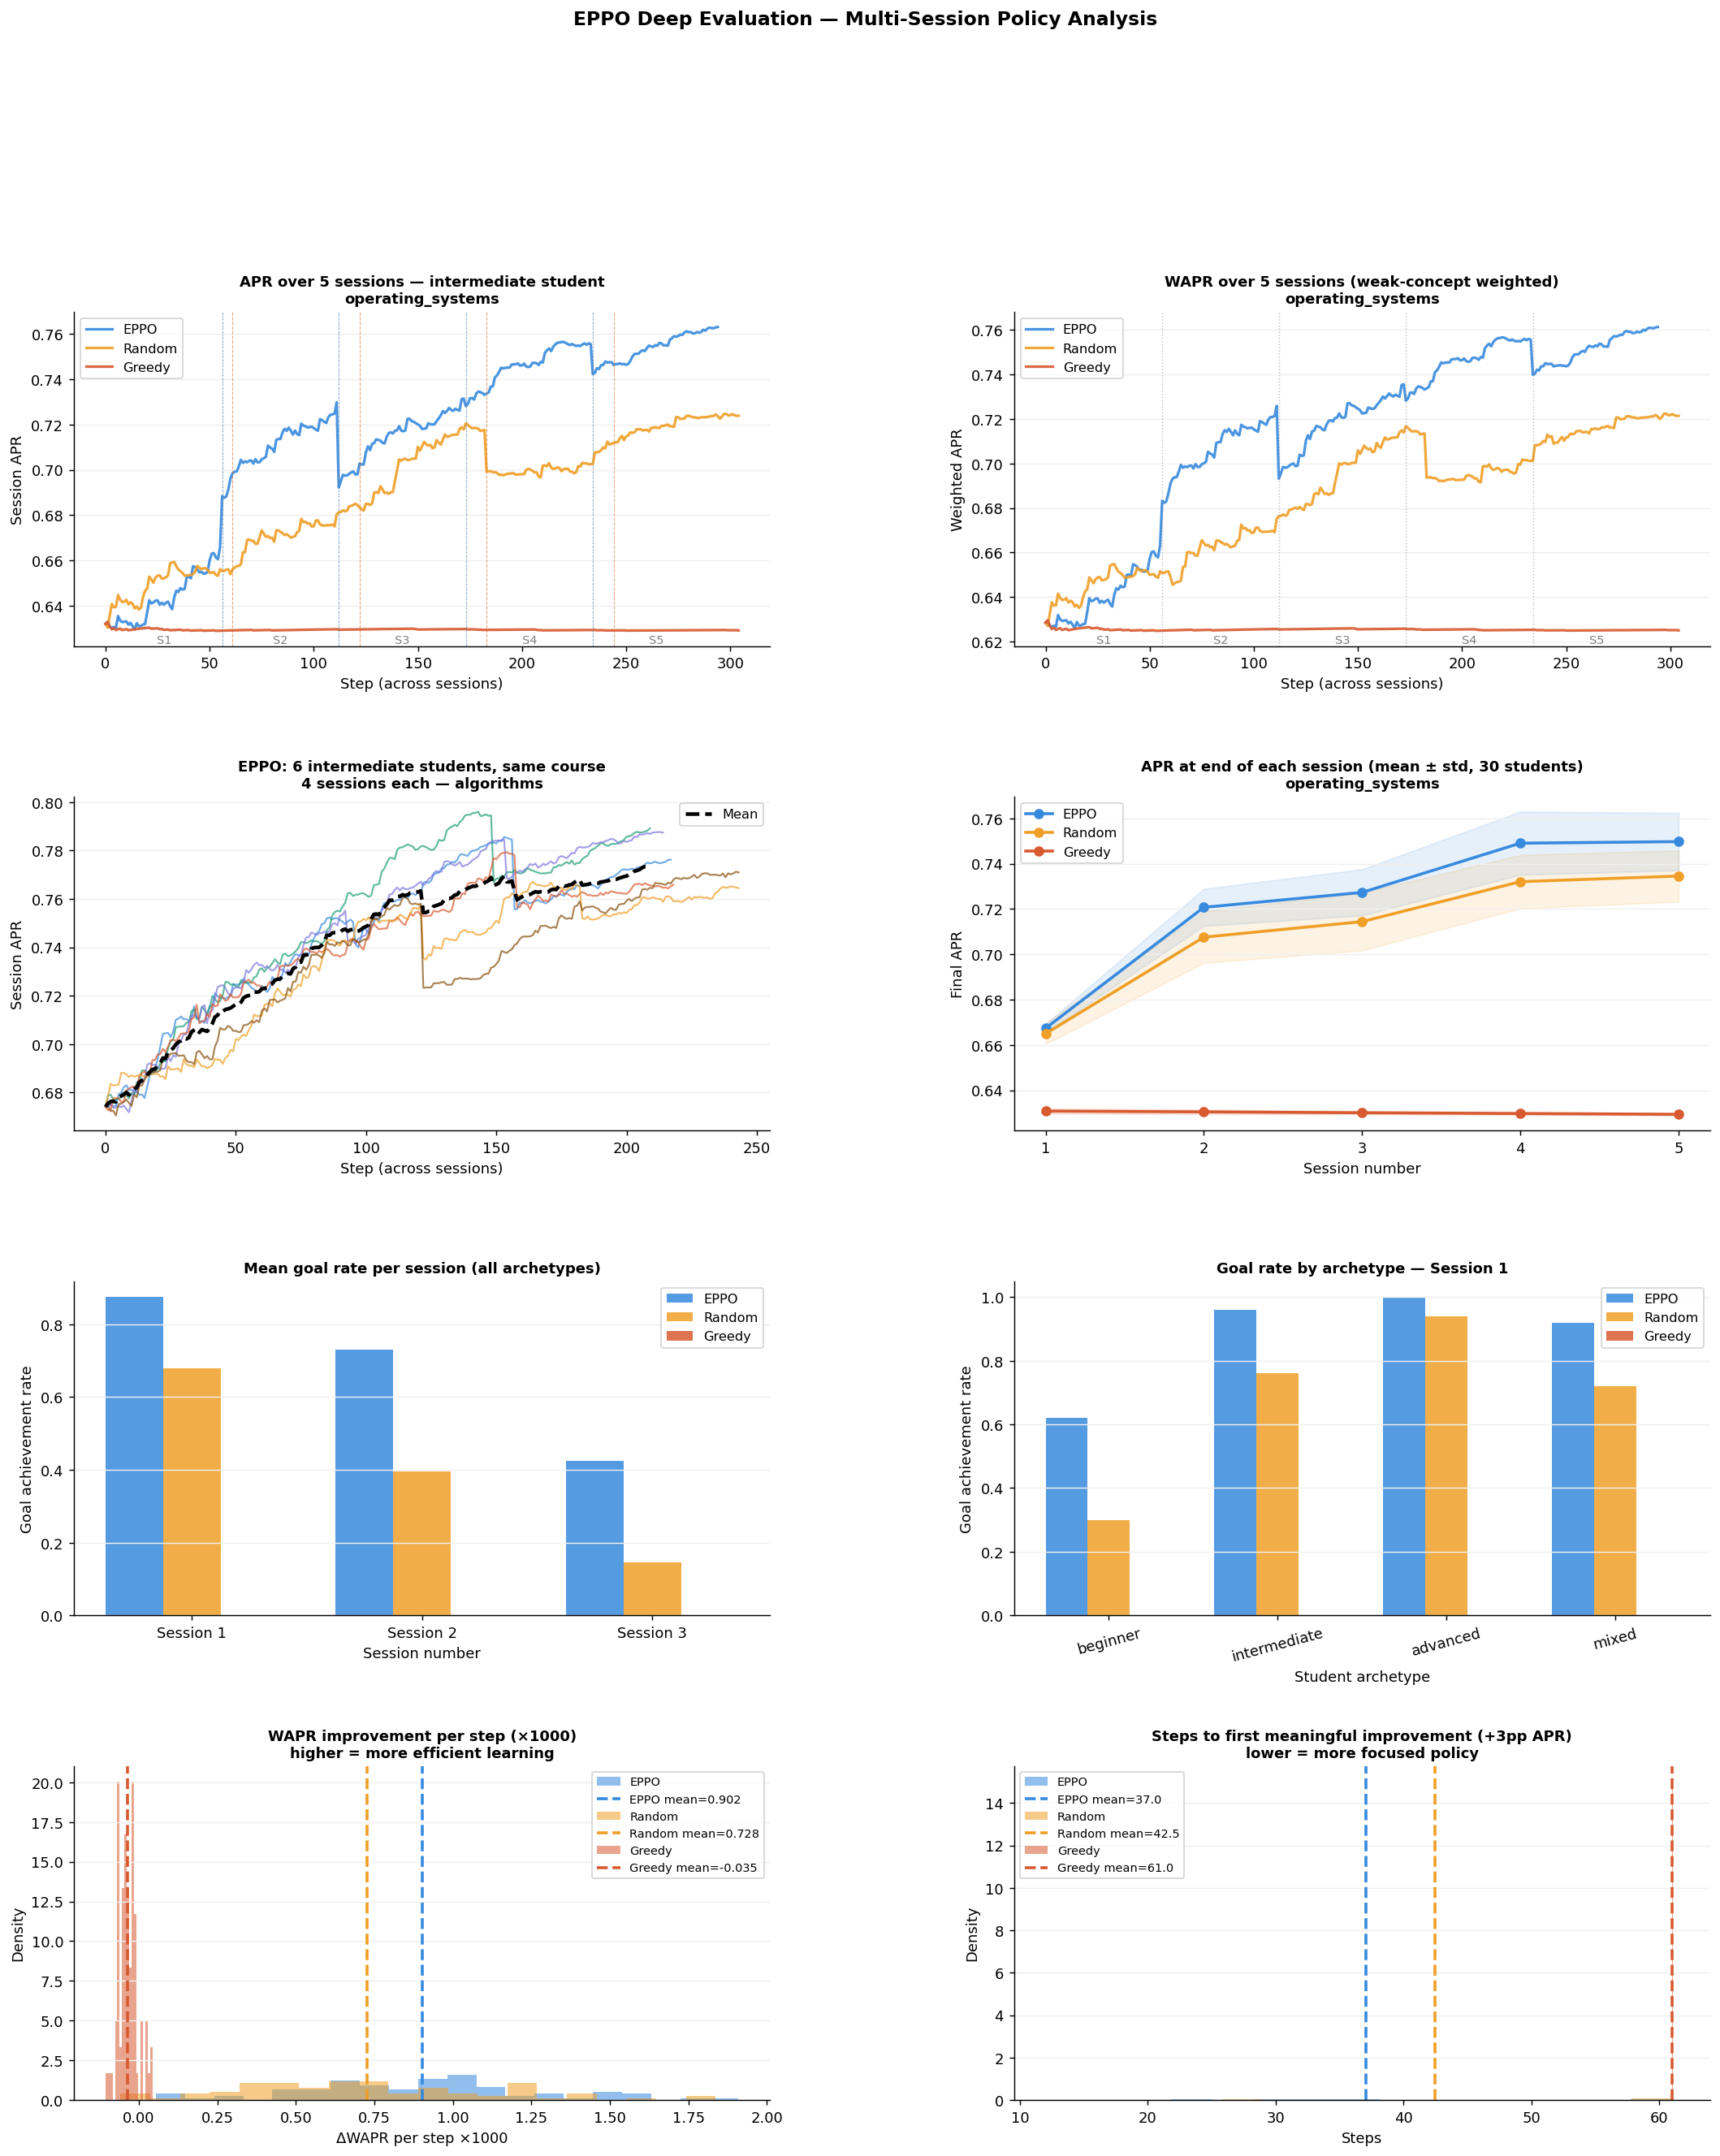

Saved: /kaggle/working/deep_eval.png

DEEP EVALUATION SUMMARY

Test 1 — APR after 5 sessions (intermediate, operating_systems):
  Policy      Start APR    End APR     Gain  Goals met
  ------------------------------------------------
  EPPO           0.6321     0.7630  +0.1309       2/5
  Random         0.6321     0.7239  +0.0918       0/5
  Greedy         0.6321     0.6292  -0.0029       0/5

Test 4 — Efficiency (80 sessions, all archetypes and courses):
  Policy      ΔWAPR/step×1k  Steps to +3pp
  ----------------------------------------
  EPPO               0.9025           37.0
  Random             0.7278           42.5
  Greedy            -0.0353           61.0

Training metrics (from metrics dict):
  Early reward (first 200 eps) : +21.478
  Late  reward (last  200 eps) : +24.328
  Peak reward                  : +42.857
  Improvement                  : +2.849


In [73]:
import os
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

matplotlib.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

# ── 1. Load best checkpoint ───────────────────────────────────────────────
CHECKPOINT_CANDIDATES = [

    '/kaggle/working/eppo_final.pt',
]
ckpt_path = next((p for p in CHECKPOINT_CANDIDATES if os.path.exists(p)), None)
if ckpt_path is None:
    raise FileNotFoundError('No checkpoint found. Upload eppo_best.pt as a Kaggle dataset.')

actor  = EPPOActor(cfg).to(DEVICE)
critic = EPPOCritic(cfg).to(DEVICE)
ckpt   = torch.load(ckpt_path, map_location=DEVICE)
if isinstance(ckpt, dict) and 'actor' in ckpt:
    actor.load_state_dict(ckpt['actor'])
    critic.load_state_dict(ckpt['critic'])
else:
    actor.load_state_dict(ckpt)
actor.eval()

# Verify
tracker.reset_global()
_s = COURSE_CONCEPT_INDICES['operating_systems'][:10]
tracker.start_session(_s)
with torch.no_grad():
    _, _lg = actor.get_policy(tracker, _s, cfg)
_std = _lg.std().item()
print(f'Checkpoint : {ckpt_path}')
print(f'Logit std  : {_std:.4f}  {"[HEALTHY]" if _std > 0.3 else "[WARNING: LOW]"}')


# ── Helper: run one session, return step-level APR and WAPR ──────────────
def run_session(policy_fn, tracker, student, cfg, rng,
                course_name, priority_indices=None):
    """
    Run one complete session.
    Returns dict with per-step metrics and session summary.
    The tracker and student are updated IN PLACE — state persists
    across sessions, simulating a returning student.
    """
    cands = COURSE_CONCEPT_INDICES[course_name]
    sidx  = preselect_session_concepts(
        tracker, cands, cfg.CONCEPT_CAP, rng,
        priority_indices=priority_indices
    )
    info  = tracker.start_session(sidx)

    step_aprs  = [tracker.compute_session_apr()]
    step_waprs = [tracker.compute_session_wapr()]
    action_history = {}
    n_mastered_before = tracker.count_newly_mastered()

    for step in range(cfg.MAX_STEPS):
        local_ci, level = policy_fn(tracker, sidx, cfg, rng)
        gci = sidx[local_ci]
        correct, _, _ = student.answer(gci, level)
        student.learn(gci, level, correct)
        tracker.update(gci, level, int(correct))
        action_history[(gci, level)] = action_history.get((gci, level), 0) + 1
        step_aprs.append(tracker.compute_session_apr())
        step_waprs.append(tracker.compute_session_wapr())
        if tracker.goal_met():
            break

    return {
        'step_aprs'   : step_aprs,
        'step_waprs'  : step_waprs,
        'final_apr'   : tracker.compute_session_apr(),
        'final_wapr'  : tracker.compute_session_wapr(),
        'apr_start'   : info['apr_start'],
        'wapr_start'  : info['wapr_start'],
        'goal_met'    : tracker.goal_met(),
        'steps'       : len(step_aprs) - 1,
        'n_mastered'  : tracker.count_newly_mastered(),
        'sidx'        : sidx,
    }


def policy_eppo(t, sidx, cfg, rng):
    actor.eval()
    with torch.no_grad(): dist, _ = actor.get_policy(t, sidx, cfg)
    flat = dist.sample().item()
    return flat // cfg.N_LEVELS, flat % cfg.N_LEVELS

def policy_random(t, sidx, cfg, rng):
    return int(rng.integers(len(sidx))), int(rng.integers(cfg.N_LEVELS))

def policy_greedy(t, sidx, cfg, rng):
    pm = [t.predict(ci, 1) for ci in sidx]
    return int(np.argmin(pm)), 1

POLICIES = [
    ('EPPO',   policy_eppo,   '#378ADD'),
    ('Random', policy_random, '#EF9F27'),
    ('Greedy', policy_greedy, '#D85A30'),
]


# ══════════════════════════════════════════════════════════════════════════
# TEST 1 — APR trajectory over 5 consecutive sessions
#           Same student, same course, all 3 policies
#           Measures: does EPPO produce faster and higher long-term APR growth?
# ══════════════════════════════════════════════════════════════════════════
print('Running Test 1: multi-session APR trajectories...')

N_SESSIONS   = 5
COURSE_T1    = 'operating_systems'
ARCHETYPE_T1 = 'intermediate'
SEED_T1      = 7

traj_results = {}
for pname, pfn, color in POLICIES:
    rng = np.random.default_rng(SEED_T1)
    tracker.reset_global()
    student = RealisticStudent.from_archetype(rng, cfg, archetype=ARCHETYPE_T1)

    # Global APR trace across all sessions (stitched)
    all_aprs   = []
    all_waprs  = []
    session_boundaries = [0]  # step indices where sessions start
    session_summaries  = []

    for sess in range(N_SESSIONS):
        result = run_session(
            pfn, tracker, student, cfg, rng, COURSE_T1
        )
        all_aprs.extend(result['step_aprs'])
        all_waprs.extend(result['step_waprs'])
        session_boundaries.append(len(all_aprs))
        session_summaries.append(result)

    traj_results[pname] = {
        'aprs'     : all_aprs,
        'waprs'    : all_waprs,
        'boundaries': session_boundaries,
        'summaries' : session_summaries,
        'color'    : color,
    }


# ══════════════════════════════════════════════════════════════════════════
# TEST 2 — Learning paths of students with similar initial knowledge
#           5 students all set to 'intermediate', same course, EPPO only
#           Measures: does the policy produce consistent paths or high variance?
# ══════════════════════════════════════════════════════════════════════════
print('Running Test 2: learning path variance across similar students...')

N_STUDENTS = 6
COURSE_T2  = 'algorithms'
N_SESS_T2  = 4

student_paths = []  # list of (aprs list, color)
COLORS_T2 = ['#378ADD','#1D9E75','#7F77DD','#D85A30','#EF9F27','#854F0B']

for sid in range(N_STUDENTS):
    rng = np.random.default_rng(sid * 13 + 42)
    tracker.reset_global()
    student = RealisticStudent.from_archetype(rng, cfg, archetype='intermediate')
    aprs = []
    for _ in range(N_SESS_T2):
        result = run_session(policy_eppo, tracker, student, cfg, rng, COURSE_T2)
        aprs.extend(result['step_aprs'])
    student_paths.append((aprs, COLORS_T2[sid]))


# ══════════════════════════════════════════════════════════════════════════
# TEST 3 — Per-archetype multi-session goal rates (100 students each)
# ══════════════════════════════════════════════════════════════════════════
print('Running Test 3: per-archetype goal rates over 3 sessions...')

arch_goal_rates = {}  # arch → {pname: [goal_rate per session]}
N_STUDENTS_T3 = 50
N_SESS_T3     = 3

for arch in ARCHETYPES:
    arch_goal_rates[arch] = {pname: [] for pname, _, _ in POLICIES}
    for sess_i in range(N_SESS_T3):
        for pname, pfn, _ in POLICIES:
            goals = []
            for sid in range(N_STUDENTS_T3):
                rng = np.random.default_rng(sid + sess_i * 100)
                tracker.reset_global()
                student = RealisticStudent.from_archetype(rng, cfg, archetype=arch)
                # Simulate prior sessions
                for prior_sess in range(sess_i):
                    rng2 = np.random.default_rng(sid + prior_sess * 1000)
                    run_session(pfn, tracker, student, cfg, rng2, COURSE_T1)
                result = run_session(pfn, tracker, student, cfg, rng, COURSE_T1)
                goals.append(float(result['goal_met']))
            arch_goal_rates[arch][pname].append(float(np.mean(goals)))


# ══════════════════════════════════════════════════════════════════════════
# TEST 4 — WAPR lift per step across difficulty levels
#           Compares efficiency on Easy vs Medium vs Hard concept sets
# ══════════════════════════════════════════════════════════════════════════
print('Running Test 4: WAPR efficiency by starting difficulty...')

# Group courses by average llm_difficulty
# algorithms: mostly 2-4, OS: 3-5, etc.
eff_results = {pname: {'wapr_per_step': [], 'steps_to_first': []}
               for pname, _, _ in POLICIES}

for pname, pfn, _ in POLICIES:
    for trial in range(80):
        rng = np.random.default_rng(trial + 500)
        arch = ARCHETYPES[trial % len(ARCHETYPES)]
        tracker.reset_global()
        student = RealisticStudent.from_archetype(rng, cfg, archetype=arch)
        course  = list(COURSE_CONCEPT_INDICES.keys())[trial % len(COURSE_CONCEPT_INDICES)]
        result  = run_session(pfn, tracker, student, cfg, rng, course)
        wapr_delta = result['final_wapr'] - result['wapr_start']
        eff_results[pname]['wapr_per_step'].append(
            wapr_delta / max(1, result['steps'])
        )
        # Steps to first mastery
        aprs = result['step_aprs']
        first_m = next(
            (i for i,a in enumerate(aprs) if a > result['apr_start'] + 0.03),
            len(aprs)
        )
        eff_results[pname]['steps_to_first'].append(first_m)

print('All tests complete. Plotting...')


# ══════════════════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 22))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

GRID_COLOR = '#f0f0f0'


# ── Plot 1a: APR trajectory across sessions ───────────────────────────────
ax1a = fig.add_subplot(gs[0, 0])
for pname, data in traj_results.items():
    aprs = data['aprs']
    ax1a.plot(aprs, color=data['color'], lw=1.8, label=pname, alpha=0.9)
    for b in data['boundaries'][1:-1]:
        ax1a.axvline(b, color=data['color'], lw=0.6, ls='--', alpha=0.4)

# Session boundary markers (shared)
first_bounds = traj_results['EPPO']['boundaries'][1:-1]
for b in first_bounds:
    ax1a.axvline(b, color='gray', lw=0.8, ls=':', alpha=0.5)

ax1a.set_title(f'APR over {N_SESSIONS} sessions — {ARCHETYPE_T1} student\n{COURSE_T1}',
               fontsize=10, fontweight='bold')
ax1a.set_xlabel('Step (across sessions)')
ax1a.set_ylabel('Session APR')
ax1a.legend(fontsize=9)
ax1a.yaxis.grid(True, color=GRID_COLOR)

# Annotate session numbers
bounds = traj_results['EPPO']['boundaries']
for i in range(N_SESSIONS):
    mid = (bounds[i] + bounds[i+1]) / 2
    ax1a.text(mid, ax1a.get_ylim()[0], f'S{i+1}',
              ha='center', va='bottom', fontsize=8, color='gray')


# ── Plot 1b: WAPR trajectory across sessions ──────────────────────────────
ax1b = fig.add_subplot(gs[0, 1])
for pname, data in traj_results.items():
    ax1b.plot(data['waprs'], color=data['color'], lw=1.8, label=pname, alpha=0.9)
for b in first_bounds:
    ax1b.axvline(b, color='gray', lw=0.8, ls=':', alpha=0.5)
ax1b.set_title(f'WAPR over {N_SESSIONS} sessions (weak-concept weighted)\n{COURSE_T1}',
               fontsize=10, fontweight='bold')
ax1b.set_xlabel('Step (across sessions)')
ax1b.set_ylabel('Weighted APR')
ax1b.legend(fontsize=9)
ax1b.yaxis.grid(True, color=GRID_COLOR)
for i in range(N_SESSIONS):
    mid = (bounds[i] + bounds[i+1]) / 2
    ax1b.text(mid, ax1b.get_ylim()[0], f'S{i+1}',
              ha='center', va='bottom', fontsize=8, color='gray')


# ── Plot 2: Learning paths of similar students ────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
max_len = max(len(p) for p,_ in student_paths)
all_path_arrs = []
for aprs, color in student_paths:
    ax2.plot(aprs, color=color, lw=1.2, alpha=0.7)
    all_path_arrs.append(np.array(aprs))

# Mean path
min_len = min(len(p) for p,_ in student_paths)
mean_path = np.mean([p[:min_len] for p,_ in student_paths], axis=0)
ax2.plot(mean_path, color='black', lw=2.5, ls='--', label='Mean', zorder=10)

# Session boundaries
# Approximate — sessions vary in length
ax2.set_title(f'EPPO: {N_STUDENTS} intermediate students, same course\n'
              f'{N_SESS_T2} sessions each — {COURSE_T2}',
              fontsize=10, fontweight='bold')
ax2.set_xlabel('Step (across sessions)')
ax2.set_ylabel('Session APR')
ax2.legend(fontsize=9)
ax2.yaxis.grid(True, color=GRID_COLOR)


# ── Plot 2b: APR at end of each session (convergence) ────────────────────
ax2b = fig.add_subplot(gs[1, 1])
# Recompute per-session final APR for all students
per_sess_final = {pname: [] for pname, _, _ in POLICIES}

for pname, pfn, color in POLICIES:
    sess_aprs = [[] for _ in range(N_SESSIONS)]
    for sid in range(30):
        rng = np.random.default_rng(sid + 999)
        tracker.reset_global()
        student = RealisticStudent.from_archetype(rng, cfg, archetype=ARCHETYPE_T1)
        for si in range(N_SESSIONS):
            result = run_session(pfn, tracker, student, cfg, rng, COURSE_T1)
            sess_aprs[si].append(result['final_apr'])
    means = [np.mean(s) for s in sess_aprs]
    stds  = [np.std(s)  for s in sess_aprs]
    xs = range(1, N_SESSIONS + 1)
    ax2b.plot(xs, means, color=color, lw=2, marker='o', ms=6, label=pname)
    ax2b.fill_between(xs,
                      [m - s for m, s in zip(means, stds)],
                      [m + s for m, s in zip(means, stds)],
                      color=color, alpha=0.12)

ax2b.set_title(f'APR at end of each session (mean ± std, 30 students)\n{COURSE_T1}',
               fontsize=10, fontweight='bold')
ax2b.set_xlabel('Session number')
ax2b.set_ylabel('Final APR')
ax2b.set_xticks(range(1, N_SESSIONS + 1))
ax2b.legend(fontsize=9)
ax2b.yaxis.grid(True, color=GRID_COLOR)


# ── Plot 3: Per-archetype goal rate across sessions ───────────────────────
ax3 = fig.add_subplot(gs[2, 0])
x     = np.arange(N_SESS_T3)
width = 0.25
for pi, (pname, _, color) in enumerate(POLICIES):
    # Average goal rate across archetypes per session
    means = []
    for si in range(N_SESS_T3):
        rates = [arch_goal_rates[arch][pname][si] for arch in ARCHETYPES]
        means.append(np.mean(rates))
    ax3.bar(x + pi * width, means, width,
            label=pname, color=color, alpha=0.85)

ax3.set_title('Mean goal rate per session (all archetypes)',
              fontsize=10, fontweight='bold')
ax3.set_xlabel('Session number')
ax3.set_ylabel('Goal achievement rate')
ax3.set_xticks(x + width)
ax3.set_xticklabels([f'Session {i+1}' for i in range(N_SESS_T3)])
ax3.legend(fontsize=9)
ax3.yaxis.grid(True, color=GRID_COLOR)


# ── Plot 3b: Per-archetype goal rate (session 1 only, bar chart) ──────────
ax3b = fig.add_subplot(gs[2, 1])
arch_x = np.arange(len(ARCHETYPES))
for pi, (pname, _, color) in enumerate(POLICIES):
    rates = [arch_goal_rates[arch][pname][0] for arch in ARCHETYPES]
    ax3b.bar(arch_x + pi * width, rates, width,
             label=pname, color=color, alpha=0.85)
ax3b.set_title('Goal rate by archetype — Session 1',
               fontsize=10, fontweight='bold')
ax3b.set_xlabel('Student archetype')
ax3b.set_ylabel('Goal achievement rate')
ax3b.set_xticks(arch_x + width)
ax3b.set_xticklabels(ARCHETYPES, rotation=15)
ax3b.legend(fontsize=9)
ax3b.yaxis.grid(True, color=GRID_COLOR)


# ── Plot 4a: WAPR/step efficiency distribution ────────────────────────────
ax4a = fig.add_subplot(gs[3, 0])
for pname, _, color in POLICIES:
    vals = np.array(eff_results[pname]['wapr_per_step']) * 1000
    ax4a.hist(vals, bins=20, color=color, alpha=0.55, label=pname, density=True)
    ax4a.axvline(vals.mean(), color=color, lw=2, ls='--',
                 label=f'{pname} mean={vals.mean():.3f}')
ax4a.set_title('WAPR improvement per step (×1000)\nhigher = more efficient learning',
               fontsize=10, fontweight='bold')
ax4a.set_xlabel('ΔWAPR per step ×1000')
ax4a.set_ylabel('Density')
ax4a.legend(fontsize=8)
ax4a.yaxis.grid(True, color=GRID_COLOR)


# ── Plot 4b: Steps to first meaningful APR improvement ───────────────────
ax4b = fig.add_subplot(gs[3, 1])
for pname, _, color in POLICIES:
    vals = np.array(eff_results[pname]['steps_to_first'])
    ax4b.hist(vals, bins=15, color=color, alpha=0.55, label=pname, density=True)
    ax4b.axvline(vals.mean(), color=color, lw=2, ls='--',
                 label=f'{pname} mean={vals.mean():.1f}')
ax4b.set_title('Steps to first meaningful improvement (+3pp APR)\nlower = more focused policy',
               fontsize=10, fontweight='bold')
ax4b.set_xlabel('Steps')
ax4b.set_ylabel('Density')
ax4b.legend(fontsize=8)
ax4b.yaxis.grid(True, color=GRID_COLOR)


plt.suptitle('EPPO Deep Evaluation — Multi-Session Policy Analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('/kaggle/working/deep_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /kaggle/working/deep_eval.png')


# ── Summary table ─────────────────────────────────────────────────────────
print('\n' + '='*70)
print('DEEP EVALUATION SUMMARY')
print('='*70)

print(f'\nTest 1 — APR after {N_SESSIONS} sessions ({ARCHETYPE_T1}, {COURSE_T1}):')
print(f'  {"Policy":<10} {"Start APR":>10} {"End APR":>10} {"Gain":>8} {"Goals met":>10}')
print('  ' + '-'*48)
for pname, data in traj_results.items():
    start = data['aprs'][0]
    end   = data['aprs'][-1]
    goals = sum(s['goal_met'] for s in data['summaries'])
    print(f'  {pname:<10} {start:>10.4f} {end:>10.4f} {end-start:>+8.4f} {goals:>7}/{N_SESSIONS}')

print(f'\nTest 4 — Efficiency (80 sessions, all archetypes and courses):')
print(f'  {"Policy":<10} {"ΔWAPR/step×1k":>14} {"Steps to +3pp":>14}')
print('  ' + '-'*40)
for pname, _, _ in POLICIES:
    wps  = np.mean(eff_results[pname]['wapr_per_step']) * 1000
    s2f  = np.mean(eff_results[pname]['steps_to_first'])
    print(f'  {pname:<10} {wps:>14.4f} {s2f:>14.1f}')

print(f'\nTraining metrics (from metrics dict):')
if 'rewards' in metrics and len(metrics['rewards']) > 0:
    early  = np.mean(metrics['rewards'][:200])
    late   = np.mean(metrics['rewards'][-200:])
    peak   = np.max(metrics['rewards'])
    print(f'  Early reward (first 200 eps) : {early:+.3f}')
    print(f'  Late  reward (last  200 eps) : {late:+.3f}')
    print(f'  Peak reward                  : {peak:+.3f}')
    print(f'  Improvement                  : {late-early:+.3f}')
print('='*70)
